# Plot Generation: Geoeconomic Pressure Analysis

*This notebook processes the cleaned metadata to generate the project's core visualizations.*

### Contents
1. **Supply Chain Realignments:** Sankey diagrams plotting pressure flows (via `plotly`).
2. **Sectoral Exposure:** Heatmaps tracking corporate presence over time (via `seaborn`).
3. **Temporal Evolution & Statistics:** Trend analysis and Chi-Square representativeness tests (via `scipy`).

In [1]:
# ==========================================
# IMPORTS AND SETUP
# ==========================================

# Standard library imports
import os
import re
import warnings

# Third-party imports (Data Manipulation & Math)
import numpy as np
import pandas as pd
from dateutil import parser
from scipy.stats import chisquare

# Third-party imports (Visualization)
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import plotly.graph_objects as go
import seaborn as sns

# API & External Data
import yfinance as yf

# Configuration 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

/Users/ThomasLUCEREAU/Downloads/RA_Clayton/Code/RA/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
"""
Process S&P 500 transcripts data.

This script loads and cleans transcript datasets, extracts standardized dates,
normalizes company names, assigns economic sectors, and retrieves missing
sector information using the Yahoo Finance API.
"""


def extract_universal_date(text):
    """
    Extract and parse a date from the beginning of a text string.

    Searches the first 150 characters of the provided string for a standard
    date pattern and attempts to parse it into a datetime object.

    Args:
        text (str): The transcript text containing the date.

    Returns:
        datetime.datetime or None: The parsed date if successfully found 
        and validated, otherwise None.
    """
    if not isinstance(text, str):
        return None

    text_start = text[:150]
    pattern = r'([A-Z][a-z]{2,8}\s+\d{1,2}(?:st|nd|rd|th)?[\s,]+\d{4})'
    match = re.search(pattern, text_start)

    if match:
        date_str = match.group(1)
        try:
            return parser.parse(date_str)
        except Exception:
            pass
            
    return None


# Load dates data and extract exact dates
df_dates = pd.read_csv("../Data/sp500_transcripts_history_full.csv")
df_dates["exact_date"] = df_dates['content'].apply(extract_universal_date)
df_dates = df_dates.dropna(subset=['exact_date'])

# Format quarter and year
df_dates["quarter_v2"] = (
    "Q" + df_dates["exact_date"]
    .dt.quarter.astype(str)
    .replace('<NA>', 'NaN')
    .replace('nan', 'NaN')
)
df_dates["year_v2"] = df_dates["exact_date"].dt.year.astype("Int64")

# Load main data and merge
data = pd.read_csv('../Data/results_final_flattened_0.csv')
data = data.merge(df_dates, on=['company', 'year', 'quarter'], how='inner')
data = data.copy()

# Drop outdated columns and rename new ones
columns_to_drop = [
    'date_str', 'quarter', 'year', 'content', 'url', 'title'
]
data.drop(
    columns=[c for c in columns_to_drop if c in data.columns],
    inplace=True,
    errors='ignore'
)
data.rename(
    columns={'quarter_v2': 'quarter', 'year_v2': 'year'},
    inplace=True
)

# Define sector lists
tech = [
    "Apple Inc. (AAPL)", "Apple (AAPL)", "Microsoft Corporation (MSFT)",
    "Microsoft (MSFT)", "Nvidia Corporation (NVDA)", "Nvidia (NVDA)",
    "Alphabet Inc. (GOOGL)", "Alphabet (GOOGL)", "Amazon.com Inc. (AMZN)",
    "Amazon (AMZN)", "Meta Platforms (META)", "Meta (META)",
    "Tesla Inc. (TSLA)", "Tesla (TSLA)", "Broadcom Inc. (AVGO)",
    "Broadcom (AVGO)", "Adobe Inc. (ADBE)", "Adobe (ADBE)",
    "Salesforce (CRM)", "Cisco Systems (CSCO)", "Cisco (CSCO)",
    "Oracle Corporation (ORCL)", "Oracle (ORCL)", "Intel Corporation (INTC)",
    "Intel (INTC)", "AMD (AMD)", "Netflix (NFLX)", "IBM (IBM)"
]

finance = [
    "JPMorgan Chase (JPM)", "Visa Inc. (V)", "Visa (V)", "Mastercard (MA)",
    "Bank of America (BAC)", "Wells Fargo (WFC)", "Goldman Sachs (GS)",
    "Morgan Stanley (MS)", "American Express (AXP)",
    "Berkshire Hathaway (BRK-B)"
]

consumer = [
    "Walmart (WMT)", "Costco (COST)", "Coca-Cola (KO)", "PepsiCo (PEP)",
    "McDonald's (MCD)", "Nike (NKE)", "Starbucks (SBUX)", "Home Depot (HD)",
    "Disney (DIS)", "Procter & Gamble (PG)"
]

health = [
    "Eli Lilly (LLY)", "UnitedHealth (UNH)", "Johnson & Johnson (JNJ)",
    "Merck (MRK)", "AbbVie (ABBV)", "Pfizer (PFE)", "Abbott (ABT)",
    "Thermo Fisher (TMO)"
]

industry_and_energy = [
    "ExxonMobil (XOM)", "Chevron (CVX)", "General Electric (GE)",
    "Boeing (BA)", "Lockheed Martin (LMT)", "Caterpillar (CAT)",
    "RTX (RTX)", "Northrop Grumman (NOC)", "General Dynamics (GD)",
    "L3Harris (LHX)", "Howmet Aerospace (HWM)", "Deere (DE)",
    "Cummins (CMI)", "PACCAR (PCAR)", "Wabtec (WAB)", "Parker-Hannifin (PH)",
    "Carrier Global (CARR)", "Johnson Controls (JCI)",
    "Rockwell Automation (ROK)", "Dover (DOV)", "Ingersoll Rand (IR)",
    "Fortive (FTV)", "Snap-on (SNA)", "Nordson (NDSN)",
    "Axon Enterprise (AXON)", "3M (MMM)", "Eaton (ETN)",
    "Emerson Electric (EMR)", "Honeywell (HON)", "Otis (OTIS)",
    "Trane Technologies (TT)"
]

transports_and_logistics = [
    "UPS (UPS)", "FedEx (FDX)", "CSX (CSX)", "Norfolk Southern (NSC)",
    "Old Dominion Freight (ODFL)", "J.B. Hunt (JBHT)", "Union Pacific (UNP)",
    "C.H. Robinson (CHRW)", "Expeditors (EXPD)"
]

airlines = [
    "Delta Air Lines (DAL)", "Southwest Airlines (LUV)",
    "United Airlines (UAL)"
]

construction = [
    "Vulcan Materials (VMC)", "Martin Marietta (MLM)",
    "Quanta Services (PWR)", "Jacobs Solutions (J)", "Waste Management (WM)",
    "Republic Services (RSG)", "Cintas (CTAS)", "Fastenal (FAST)"
]

all_companies = (
    tech + finance + consumer + health + industry_and_energy +
    transports_and_logistics + airlines + construction
)

# Map company names to their common prefixes
grouped_by_ticker = {}
for item in all_companies:
    match = re.search(r'\(([^)]+)\)', item)
    if match:
        ticker = match.group(1)
        name_part = item[:match.start()].strip()
        if ticker not in grouped_by_ticker:
            grouped_by_ticker[ticker] = []
        grouped_by_ticker[ticker].append(name_part)

rename_mapping = {}
for item in all_companies:
    match = re.search(r'\(([^)]+)\)', item)
    if match:
        ticker = match.group(1)
        common_name = os.path.commonprefix(grouped_by_ticker[ticker]).strip()
        rename_mapping[item] = f"{common_name} ({ticker})"

data['company'] = data['company'].replace(rename_mapping)


def get_ticker_from_company(name):
    """
    Extract the ticker symbol from a company name string.

    Args:
        name (str): The company name containing the ticker in parentheses.

    Returns:
        str: The extracted ticker symbol, or the original name if no 
        parentheses are found.
    """
    match = re.search(r'\(([^)]+)\)', name)
    return match.group(1) if match else name


data['ticker'] = data['company'].apply(get_ticker_from_company)

# Assign sectors based on predefined lists
sector_mapping = {}
for c in tech:
    sector_mapping[rename_mapping.get(c, c)] = 'Tech'
for c in finance:
    sector_mapping[rename_mapping.get(c, c)] = 'Finance'
for c in consumer:
    sector_mapping[rename_mapping.get(c, c)] = 'Consumer'
for c in health:
    sector_mapping[rename_mapping.get(c, c)] = 'Health'
for c in industry_and_energy:
    sector_mapping[rename_mapping.get(c, c)] = 'Industry & Energy'
for c in transports_and_logistics:
    sector_mapping[rename_mapping.get(c, c)] = 'Transports'
for c in airlines:
    sector_mapping[rename_mapping.get(c, c)] = 'Airlines'
for c in construction:
    sector_mapping[rename_mapping.get(c, c)] = 'Construction'

data['sector'] = data['company'].map(sector_mapping)


def get_sectors_yfinance(ticker):
    """
    Retrieve the sector of a company using the yfinance API.

    Args:
        ticker (str): The stock ticker symbol.

    Returns:
        str: The company's sector, or 'Other' if not found or an error occurs.
    """
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        if info and isinstance(info, dict):
            return info.get('sector', 'Other')
    except Exception:
        pass
        
    return 'Other'


# Fill missing sectors using the Yahoo Finance API
missing_mask = data['sector'].isna()
if missing_mask.any():
    data.loc[missing_mask, 'sector'] = data.loc[missing_mask, 'ticker'].apply(
        get_sectors_yfinance
    )

data['sector'] = data['sector'].fillna('Other')
data.drop_duplicates(inplace=True)

# Display final outputs
print("\n--- ACTUAL CALENDAR DISTRIBUTION OF TRANSCRIPTS ---")
distribution = data.groupby(['year', 'quarter']).size().reset_index(
    name='transcript_count'
)
distribution = distribution.sort_values(by=['year', 'quarter'])
print(distribution.to_string(index=False))

print("-" * 60)
print(f"Total transcripts: {len(data)}")
print(data.groupby('sector')['company'].nunique())
print("-" * 60)


--- ACTUAL CALENDAR DISTRIBUTION OF TRANSCRIPTS ---
 year quarter  transcript_count
 2022      Q2                 3
 2022      Q3                 6
 2022      Q4                10
 2023      Q1                13
 2023      Q2                28
 2023      Q3                47
 2023      Q4                49
 2024      Q1                48
 2024      Q2                51
 2024      Q3                47
 2024      Q4                57
 2025      Q1                54
 2025      Q2                 5
 2025      Q3                41
 2025      Q4                16
 2026      Q1                 5
------------------------------------------------------------
Total transcripts: 480
sector
Airlines              2
Construction          5
Consumer              9
Finance               8
Health                7
Industry & Energy    22
Tech                 15
Transports            6
Name: company, dtype: int64
------------------------------------------------------------


In [3]:
data.head()

,company,tariffs_summary,tariffs_effect_any,tariffs_effect_current,tariffs_effect_future,tariffs_investment_up_imposing,tariffs_investment_up_receiving,tariffs_investment_up_third_party,tariffs_investment_down_imposing,tariffs_investment_down_receiving,...,sanctions_hs_heading_explanation,sanctions_hs_subheading_explanation,exports_hs_chapter_explanation,exports_hs_heading_explanation,exports_hs_subheading_explanation,sector,exact_date,quarter,year,ticker
0,Apple (AAPL),[Part 5] Apple is monitoring the situation reg...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-01-30,Q1,2025,AAPL
1,Apple (AAPL),"[Part 1] Apple is affected by tariffs, with es...",1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-07-31,Q3,2025,AAPL
2,Microsoft (MSFT),Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2024-10-30,Q4,2024,MSFT
3,Microsoft (MSFT),[Part 3] Microsoft's Windows OEM revenue may b...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-01-29,Q1,2025,MSFT
4,Microsoft (MSFT),Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-07-30,Q3,2025,MSFT


In [4]:
"""
Clean and process imposing and receiving country columns.

This script identifies related imposing and receiving country columns, 
cleans their string representations, and handles overlaps (excluding 'various') 
by merging the sets if a genuine overlap exists.
"""

# Extract prefixes to process matching imposing and receiving columns
cols_imposing = [c for c in data.columns if 'countries_imposing' in c]
prefixes = [c.replace('countries_imposing', '') for c in cols_imposing]


def process_excluding_various(row, col_imp, col_rec):
    """
    Process and merge imposing and receiving countries for a given row.

    If there are specific countries (other than 'various') common to both
    imposing and receiving sets, the sets are merged. Otherwise, they are
    kept separate, cleaned, and sorted.

    Args:
        row (pd.Series): A single row from the pandas DataFrame.
        col_imp (str): The column name containing imposing countries.
        col_rec (str): The column name containing receiving countries.

    Returns:
        tuple: A tuple of strings (imposing_str, receiving_str) containing
        the processed country lists.
    """

    def to_set(val):
        """Convert a stringified list of countries into a clean set."""
        if pd.isna(val) or str(val).lower() == 'nan':
            return set()
        
        # Remove brackets and quotes, and standardize separators
        cleaned_str = (
            str(val)
            .replace('[', '')
            .replace(']', '')
            .replace("'", "")
            .replace(';', ',')
        )
        # Use set comprehension for cleaner and faster execution
        return {c.strip() for c in cleaned_str.split(',') if c.strip()}

    set_imp = to_set(row[col_imp])
    set_rec = to_set(row[col_rec])

    # Identify common countries, excluding the generic 'various' category
    common_elements = set_imp.intersection(set_rec)
    real_countries_in_common = [
        c for c in common_elements if c.lower() != 'various'
    ]

    # If they share real countries, merge them. Otherwise, keep them separated.
    if len(real_countries_in_common) > 0:
        merged_str = ', '.join(sorted(set_imp.union(set_rec)))
        return merged_str, merged_str
    
    return ', '.join(sorted(set_imp)), ', '.join(sorted(set_rec))


# Apply the processing logic to all matching prefix column pairs
for pref in prefixes:
    c_imp = f"{pref}countries_imposing"
    c_rec = f"{pref}countries_receiving"
    
    if c_imp in data.columns and c_rec in data.columns:
        res = data.apply(
            lambda r: process_excluding_various(r, c_imp, c_rec),
            axis=1
        )
        data[c_imp] = res.map(lambda x: x[0])
        data[c_rec] = res.map(lambda x: x[1])

In [ ]:
"""
Generate a Sankey diagram for geoeconomic pressures.

This script aggregates data on tariffs, sanctions, and export controls 
to visualize the flow of pressures from imposing countries, through 
economic sectors, down to receiving countries using Plotly.
"""

# DATA PREPARATION & RESTRUCTURING
prefixes = ['tariffs_', 'sanctions_', 'exports_']
df_list = []

for prefix in prefixes:
    col_imposing = f"{prefix}countries_imposing"
    col_receiving = f"{prefix}countries_receiving"
    
    # Extract relevant columns for the specific policy type
    subset_df = data[[col_imposing, 'sector', col_receiving]].copy()
    
    # Fill missing values
    subset_df[col_imposing] = subset_df[col_imposing].fillna('Unspecified')
    subset_df[col_receiving] = subset_df[col_receiving].fillna('Unspecified')
    
    # Filter out rows where both ends of the flow are Unspecified
    valid_mask = ~(
        (subset_df[col_imposing] == 'Unspecified') & 
        (subset_df[col_receiving] == 'Unspecified')
    )
    subset_df = subset_df[valid_mask]
    
    # Standardize column names for clean concatenation
    subset_df.rename(columns={
        col_imposing: 'countries_imposing',
        col_receiving: 'countries_receiving'
    }, inplace=True)
    
    df_list.append(subset_df)

# Combine all policy types into a single dataframe
df_sankey = pd.concat(df_list, ignore_index=True)

# Clean string representations (remove brackets, quotes, unify separators)
for col in ['countries_imposing', 'countries_receiving']:
    df_sankey[col] = (
        df_sankey[col]
        .astype(str)
        .str.replace(r"[\[\]'\"]", "", regex=True)
        .str.replace(";", ",")
        .str.split(',')
    )

# Explode lists into separate rows to create node mappings
df_sankey = (
    df_sankey
    .explode('countries_imposing')
    .explode('countries_receiving')
)

# Strip whitespaces and filter out empty strings
for col in ['countries_imposing', 'sector', 'countries_receiving']:
    df_sankey[col] = df_sankey[col].astype(str).str.strip()
    df_sankey = df_sankey[df_sankey[col] != '']


# AGGREGATION & SIZING
# Count flows between sender, sector, and target
flow_counts = (
    df_sankey.groupby(['countries_imposing', 'sector', 'countries_receiving'])
    .size()
    .reset_index(name='value')
).sort_values('value', ascending=False)

# Calculate global node sizes to sort them properly
source_sizes = (
    flow_counts.groupby('countries_imposing')['value']
    .sum().sort_values(ascending=False)
)
sector_sizes = (
    flow_counts.groupby('sector')['value']
    .sum().sort_values(ascending=False)
)
target_sizes = (
    flow_counts.groupby('countries_receiving')['value']
    .sum().sort_values(ascending=False)
)

sources = source_sizes.index.tolist()
sectors = sector_sizes.index.tolist()
targets = target_sizes.index.tolist()

labels = sources + sectors + targets

# Map node names to specific indices for Plotly
source_dict = {name: i for i, name in enumerate(sources)}
sector_dict = {name: i + len(sources) for i, name in enumerate(sectors)}
target_dict = {
    name: i + len(sources) + len(sectors) for i, name in enumerate(targets)
}


# COLOR MANAGEMENT (Academic / Institutional Palette)
academic_palette = [
    '#003399',  # Deep European Blue
    '#8B0000',  # Dark Red / Maroon
    '#4682B4',  # Steel Blue
    '#556B2F',  # Dark Olive Green
    '#D2691E',  # Rust / Ochre
    '#708090',  # Slate Gray
    '#008080',  # Teal
    '#B8860B'   # Dark Goldenrod
]

def hex_to_rgba(hex_color, alpha=0.35):
    """
    Convert a HEX color code to an RGBA string with transparency.
    
    Args:
        hex_color (str): The hex color string (e.g., '#FFFFFF').
        alpha (float): The opacity level between 0 and 1.
        
    Returns:
        str: Formatted RGBA string.
    """
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r}, {g}, {b}, {alpha})'

# Map colors strictly to imposing countries
country_node_colors = {}
country_link_colors = {}

for i, country in enumerate(sources):
    color = academic_palette[i % len(academic_palette)]
    country_node_colors[country] = color
    country_link_colors[country] = hex_to_rgba(color, 0.35)

# Assign colors to all visible nodes
node_colors = []
for node in labels:
    if node in sources:
        node_colors.append(country_node_colors[node])
    elif node in targets and node not in sources:
        node_colors.append('#E0E0E0')  # Light grey for pure target countries
    else:
        node_colors.append('#A9A9A9')  # Darker grey for economic sectors

# Links take the color of their origin country
base_colors = [
    country_link_colors[country] 
    for country in flow_counts['countries_imposing']
]
# Since we map source to sector and sector to target, link lists are duplicated
link_colors = base_colors + base_colors


# SPATIAL POSITIONING & PLOTTING
def get_y_positions(n):
    """
    Calculate evenly distributed vertical coordinates for Sankey nodes.
    
    Args:
        n (int): Number of nodes in the layer.
        
    Returns:
        list of float: List of Y-coordinates bounded between 0 and 1.
    """
    if n == 0:
        return []
    if n == 1:
        return [0.5]
    return [0.05 + i * (0.90 / (n - 1)) for i in range(n)]

x_pos = (
    [0.01] * len(sources) + 
    [0.5] * len(sectors) + 
    [0.99] * len(targets)
)
y_pos = (
    get_y_positions(len(sources)) + 
    get_y_positions(len(sectors)) + 
    get_y_positions(len(targets))
)

# Flow from imposing countries to sectors
source_to_sector_sources = (
    flow_counts['countries_imposing'].map(source_dict).tolist()
)
source_to_sector_targets = flow_counts['sector'].map(sector_dict).tolist()

# Flow from sectors to receiving countries
sector_to_target_sources = flow_counts['sector'].map(sector_dict).tolist()
sector_to_target_targets = (
    flow_counts['countries_receiving'].map(target_dict).tolist()
)

sankey_sources = source_to_sector_sources + sector_to_target_sources
sankey_targets = source_to_sector_targets + sector_to_target_targets
sankey_values = flow_counts['value'].tolist() + flow_counts['value'].tolist()

# Generate the interactive Plotly Figure with Academic Formatting
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=15,
        line=dict(color="black", width=0.5),
        label=labels,
        color=node_colors,
        x=x_pos,
        y=y_pos
    ),
    link=dict(
        source=sankey_sources,
        target=sankey_targets,
        value=sankey_values,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="Figure 1: Bilateral Flows of Geoeconomic Pressures by Sector",
    font=dict(
        family="Times New Roman, serif",
        size=14,
        color="black"
    ),
    height=750,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(t=60, l=20, r=20, b=20)
)

# Display or export the figure
try:
    fig.show()
    print("Figure: Sankey Diagram successfully rendered inline.")
    
except Exception:
    print("Note: Inline interactive visualization is unavailable in the current environment.")
    print("Exporting the figure to HTML format...")
    
    os.makedirs("outputs", exist_ok=True)
    out_path = "outputs/sankey_geoeconomic_pressures.html"
    fig.write_html(out_path)
    
    print(f"Success: Figure exported locally to '{out_path}'.")

Figure: Sankey Diagram successfully rendered inline.


### Dataset Consolidation: the two-stage LLM Inference

In this section, we consolidate our data by merging the outputs of the **two-stage prompting methodology** used to process the earnings calls:
1. **First-Stage Prompt (Policy Detection):** A baseline classification generating boolean flags to identify whether a document discusses specific geoeconomic instruments (e.g., tariffs, sanctions, export controls).
2. **Second-Stage Prompt (Granular Extraction):** A deep-dive structured JSON extraction—run exclusively on flagged documents—to identify the *sender*, *receiver*, *means* (products/sectors), and firm-level responses (e.g., supply chain readjustments, pricing, R&D).

By merging these two outputs alongside our exact calendar metadata, we construct the unified, high-dimensional dataset required for our downstream visualizations and statistical analysis.

In [ ]:
# Load and merge with the exact calendar data
# Note: Ensure the file paths correspond correctly to your Prompt 1 vs Prompt 2 datasets
df_extraction = pd.read_csv('../Data/results_final_flattened_0.csv')
df_extraction = df_extraction.merge(
    df_dates, 
    on=['company', 'year', 'quarter'], 
    how='inner'
)

# Safely drop legacy temporal columns
columns_to_drop = [
    'date', 'date_str', 'exact_date', 'quarter', 
    'year', 'content', 'url', 'title'
]
df_extraction.drop(
    columns=[c for c in columns_to_drop if c in df_extraction.columns], 
    inplace=True, 
    errors='ignore'
)

# Switch to the corrected calendar timeline
df_extraction.rename(
    columns={'quarter_v2': 'quarter', 'year_v2': 'year'}, 
    inplace=True
)

# Generate the ticker column
df_extraction['ticker'] = df_extraction['company'].apply(
    get_ticker_from_company
)

# Drop the 'company' variable to prevent preliminary conflicts during merge
df_extraction.drop(columns=['company'], inplace=True, errors='ignore')

# PREVENT DUPLICATE COLUMNS (_x and _y SUFFIXES)
# Identify columns that exist in both DataFrames (excluding the merge keys)
merge_keys = ['ticker', 'year', 'quarter']
overlapping_cols = [
    col for col in df_extraction.columns 
    if col in data.columns and col not in merge_keys
]

# Drop overlapping columns from df_extraction so Pandas uses the metadata from 'data'
df_extraction.drop(columns=overlapping_cols, inplace=True, errors='ignore')

# Final outer merge to align the datasets
df_merged_outer = pd.merge(
    df_extraction, 
    data, 
    on=merge_keys, 
    how='outer', 
    indicator=True
)

# Mismatch analysis
df_mismatches = df_merged_outer[df_merged_outer['_merge'] != 'both']

print("-" * 60)
print(f"Number of unique mismatched rows: {len(df_mismatches)}")
print("-" * 60)

# Display the source of orphaned rows for debugging purposes
if len(df_mismatches) > 0:
    print("Mismatch details by source:")
    print(df_mismatches['_merge'].value_counts().to_string())
    print("\nExamples of orphaned rows:")
    display(df_mismatches[['ticker', 'year', 'quarter', '_merge']].head(5))

# Extract the accurately matched dataset for downstream visualization
data_merged = df_merged_outer[df_merged_outer['_merge'] == 'both'].copy()
data_merged.drop(columns=['_merge'], inplace=True, errors='ignore')

# If sector resolution is needed after dropping duplicates:
if 'sector_y' in data_merged.columns and 'sector_x' in data_merged.columns:
    data_merged['sector'] = data_merged['sector_y'].fillna(data_merged['sector_x'])
    data_merged.drop(columns=['sector_x', 'sector_y'], inplace=True, errors='ignore')

------------------------------------------------------------
Number of unique mismatched rows: 0
------------------------------------------------------------


In [25]:
"""
Generate multiple Sankey diagrams for various geoeconomic measures.

This script loops through tariffs, export controls, and sanctions to 
visualize the bilateral flows of pressures. It applies dynamic country 
retrieval via the Yahoo Finance API for unresolved tickers and exports 
the final interactive and static figures.
"""

# Extract the accurately matched dataset from the previous merge
data_merged = df_merged_outer[df_merged_outer['_merge'] == 'both'].copy()
data_merged.drop(columns=['_merge'], inplace=True, errors='ignore')


# ==========================================
# CONFIGURATION AND DICTIONARIES
# ==========================================
# FIXED: Using the exact column names from your Prompt 2 dataset
measures = ['tariffs_effect_any', 'exports_effect_any', 'sanctions_effect_any']

measure_names = {
    'tariffs_effect_any': 'Tariffs',
    'exports_effect_any': 'Export Controls',
    'sanctions_effect_any': 'Sanctions'
}

prefix_map = {
    'tariffs_effect_any': 'tariffs_',
    'exports_effect_any': 'exports_',
    'sanctions_effect_any': 'sanctions_'
}

academic_palette = [
    '#003399',  # Deep European Blue
    '#8B0000',  # Dark Red / Maroon
    '#4682B4',  # Steel Blue
    '#556B2F',  # Dark Olive Green
    '#D2691E',  # Rust / Ochre
    '#708090',  # Slate Gray
    '#008080',  # Teal
    '#B8860B'   # Dark Goldenrod
]

# GLOBAL HELPERS
country_cache = {}


def hex_to_rgba(hex_color, alpha=0.35):
    """
    Convert a HEX color code to an RGBA string with transparency.
    """
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r}, {g}, {b}, {alpha})'


def get_y_positions(n):
    """
    Calculate evenly distributed vertical coordinates for Sankey nodes.
    """
    if n == 0:
        return []
    if n == 1:
        return [0.5]
    return [0.05 + i * (0.90 / (n - 1)) for i in range(n)]


def resolve_country_with_yfinance(row):
    """
    Resolve missing country information using ticker symbols.
    """
    imp = str(row['countries_imposing'])
    rec = str(row['countries_receiving'])
    
    match_imp = re.search(r'\(([^)]+)\)', imp)
    match_rec = re.search(r'\(([^)]+)\)', rec)
    
    if match_imp or match_rec:
        ticker = match_rec.group(1) if match_rec else match_imp.group(1)
        
        if ticker not in country_cache:
            try:
                stock_info = yf.Ticker(ticker).info
                country_cache[ticker] = stock_info.get(
                    'country', 'United States'
                )
            except Exception:
                country_cache[ticker] = 'United States'
        
        row['countries_receiving'] = country_cache[ticker]
        row['countries_imposing'] = 'Various'
        
    return row


# ==========================================
# MAIN LOOP FOR DIAGRAM GENERATION
# ==========================================
os.makedirs("outputs", exist_ok=True)

for measure in measures:
    print(f"\nProcessing Sankey diagram for: {measure_names[measure]}...")
    
    prefix = prefix_map[measure]
    col_imposing = f"{prefix}countries_imposing"
    col_receiving = f"{prefix}countries_receiving"
    
    # Filter dataset for the active measure
    df_base = data_merged[data_merged[measure] == 1].copy()
    
    if df_base.empty:
        print(f"Notice: No data available for {measure_names[measure]}.")
        continue
        
    df_sankey = df_base[[col_imposing, 'sector', col_receiving]].copy()

    # Handle missing values
    df_sankey[col_imposing] = df_sankey[col_imposing].fillna('Unspecified')
    df_sankey[col_receiving] = df_sankey[col_receiving].fillna('Unspecified')
    
    valid_mask = ~(
        (df_sankey[col_imposing] == 'Unspecified') & 
        (df_sankey[col_receiving] == 'Unspecified')
    )
    df_sankey = df_sankey[valid_mask]

    df_sankey.rename(columns={
        col_imposing: 'countries_imposing',
        col_receiving: 'countries_receiving'
    }, inplace=True)

    # Clean string representations
    for col in ['countries_imposing', 'countries_receiving']:
        df_sankey[col] = (
            df_sankey[col]
            .astype(str)
            .str.replace(r"[\[\]'\"]", "", regex=True)
            .str.replace(";", ",")
            .str.split(',')
        )

    # Explode node mappings
    df_sankey = (
        df_sankey
        .explode('countries_imposing')
        .explode('countries_receiving')
    )

    # Strip whitespaces and drop empty links
    for col in ['countries_imposing', 'sector', 'countries_receiving']:
        df_sankey[col] = df_sankey[col].astype(str).str.strip()
        df_sankey = df_sankey[df_sankey[col] != '']

    # Apply external API resolution
    if not df_sankey.empty:
        df_sankey = df_sankey.apply(resolve_country_with_yfinance, axis=1)

    # Aggregate flows
    flow_counts = (
        df_sankey.groupby(
            ['countries_imposing', 'sector', 'countries_receiving']
        )
        .size()
        .reset_index(name='value')
    ).sort_values('value', ascending=False)

    source_sizes = (
        flow_counts.groupby('countries_imposing')['value']
        .sum().sort_values(ascending=False)
    )
    sector_sizes = (
        flow_counts.groupby('sector')['value']
        .sum().sort_values(ascending=False)
    )
    target_sizes = (
        flow_counts.groupby('countries_receiving')['value']
        .sum().sort_values(ascending=False)
    )

    sources = source_sizes.index.tolist()
    sectors = sector_sizes.index.tolist()
    targets = target_sizes.index.tolist()

    labels = sources + sectors + targets

    # Node indexing
    source_dict = {name: i for i, name in enumerate(sources)}
    sector_dict = {name: i + len(sources) for i, name in enumerate(sectors)}
    target_dict = {
        name: i + len(sources) + len(sectors) for i, name in enumerate(targets)
    }

    # Color allocation
    country_node_colors = {}
    country_link_colors = {}

    for i, country in enumerate(sources):
        color = academic_palette[i % len(academic_palette)]
        country_node_colors[country] = color
        country_link_colors[country] = hex_to_rgba(color, 0.35)

    node_colors = []
    for node in labels:
        if node in sources:
            node_colors.append(country_node_colors[node])
        elif node in targets and node not in sources:
            node_colors.append('#E0E0E0')
        else:
            node_colors.append('#A9A9A9')

    base_colors = [
        country_link_colors[country] 
        for country in flow_counts['countries_imposing']
    ]
    link_colors = base_colors + base_colors

    # Node coordinates
    x_pos = (
        [0.01] * len(sources) + 
        [0.5] * len(sectors) + 
        [0.99] * len(targets)
    )
    y_pos = (
        get_y_positions(len(sources)) + 
        get_y_positions(len(sectors)) + 
        get_y_positions(len(targets))
    )

    # Link paths
    source_to_sector_sources = (
        flow_counts['countries_imposing'].map(source_dict).tolist()
    )
    source_to_sector_targets = flow_counts['sector'].map(sector_dict).tolist()
    sector_to_target_sources = flow_counts['sector'].map(sector_dict).tolist()
    sector_to_target_targets = (
        flow_counts['countries_receiving'].map(target_dict).tolist()
    )

    sankey_sources = source_to_sector_sources + sector_to_target_sources
    sankey_targets = source_to_sector_targets + sector_to_target_targets
    sankey_values = (
        flow_counts['value'].tolist() + flow_counts['value'].tolist()
    )

    # Figure initialization
    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=15,
            line=dict(color="black", width=0.5),
            label=labels,
            color=node_colors,
            x=x_pos,
            y=y_pos
        ),
        link=dict(
            source=sankey_sources,
            target=sankey_targets,
            value=sankey_values,
            color=link_colors
        )
    )])

    chart_title = (
        f"Figure: Bilateral Flows of Geoeconomic Pressures - "
        f"{measure_names[measure]}"
    )
    
    fig.update_layout(
        title_text=chart_title,
        font=dict(
            family="Times New Roman, serif",
            size=14,
            color="black"
        ),
        height=750,
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(t=60, l=20, r=20, b=20)
    )

    # Exportation and rendering
    filename_html = f"outputs/sankey_{measure}.html"
    filename_png = f"outputs/sankey_{measure}.png" 

    # Attempt saving static PNG (Requires kaleido)
    try:
        fig.write_image(filename_png, width=1200, height=800, scale=2)
        print(f"Success: Static image exported to '{filename_png}'")
    except Exception:
        pass
    # Attempt saving interactive HTML
    try:
        fig.write_html(filename_html)
    except Exception as e:
        pass
    # Attempt inline rendering
    try:
        fig.show()
    except Exception:
        pass


Processing Sankey diagram for: Tariffs...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: E.G. CHINA"}}}



Processing Sankey diagram for: Export Controls...



Processing Sankey diagram for: Sanctions...


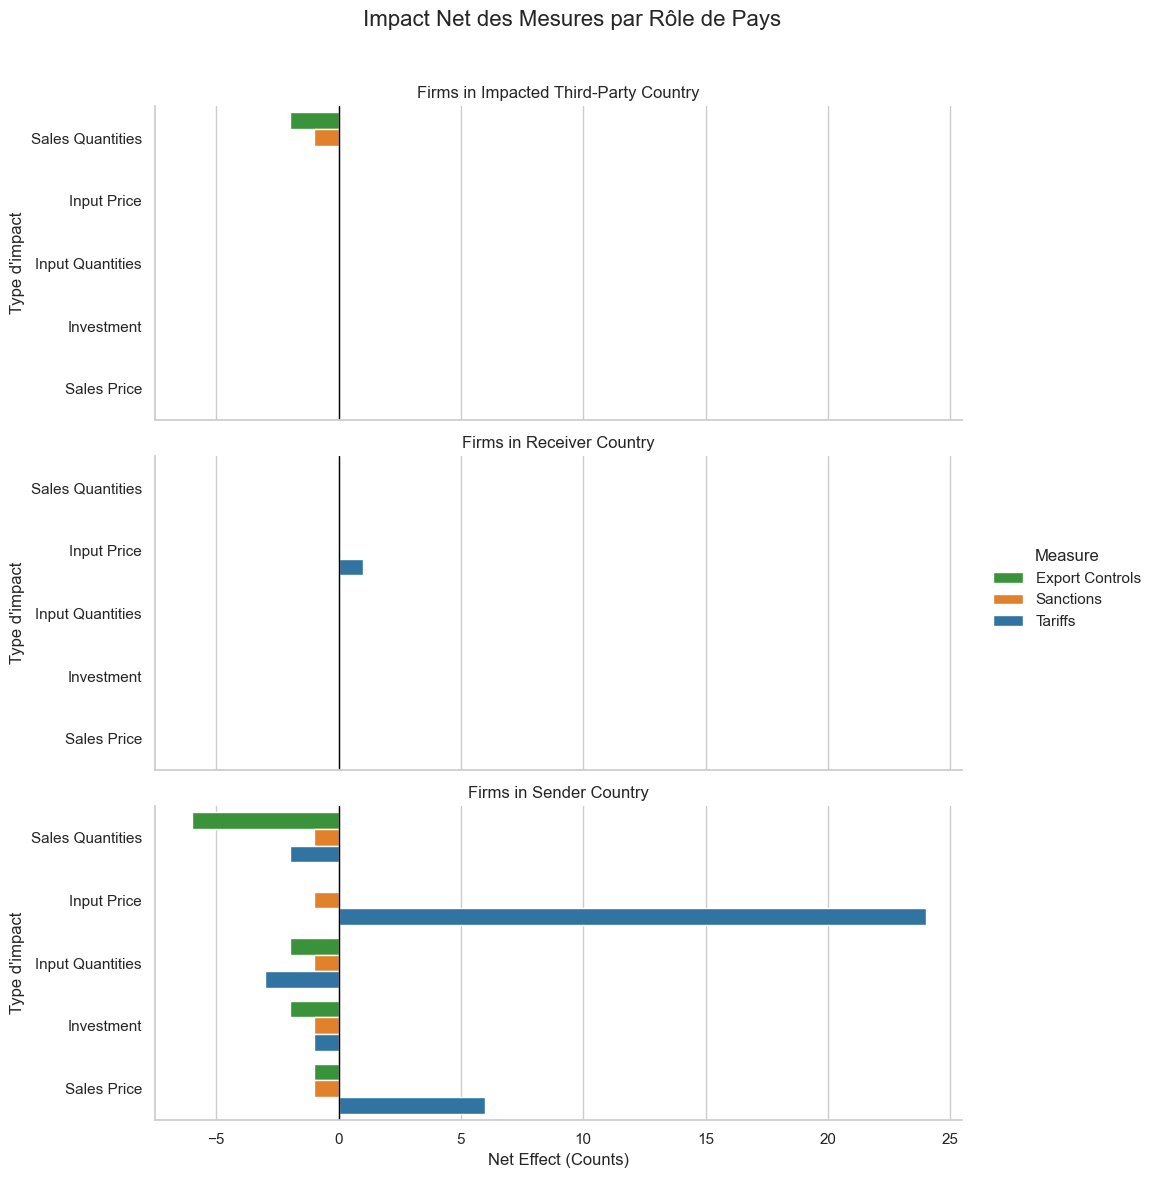

In [ ]:
"""
Analyze and visualize firm-level responses to geoeconomic pressures.

This script processes the merged dataset to categorize the role of each 
firm's home country (Sender, Receiver, or Third-Party) and aggregates 
their net reported outcomes (e.g., investment, sales, prices) across 
different policy measures.
"""

df = data_merged.copy()

# DATA PREPARATION
country_synonyms = {
    'united states': 'usa', 'us': 'usa', 'america': 'usa',
    'china': 'china', 'prc': 'china',
    'russia': 'russia', 'russian federation': 'russia'
}

def get_ticker_from_company(company_name):
    """
    Extract the ticker symbol from a company name string.
    
    Args:
        company_name (str): The full company name.
        
    Returns:
        str: The extracted ticker or the original name if none is found.
    """
    if pd.isna(company_name):
        return 'UNKNOWN'
    match = re.search(r'\(([^)]+)\)', str(company_name))
    return match.group(1) if match else str(company_name)


# Default ticker mapping (can be expanded based on your dataset)
ticker_to_country = {'TTE': 'france', '00981': 'china'}

if 'ticker_x' in df.columns:
    df['ticker'] = df['ticker_x']
elif 'ticker' not in df.columns:
    df['ticker'] = df['company'].apply(get_ticker_from_company)

# Assign firm home country (defaults to 'usa' as per original logic)
df['firm_country'] = df['ticker'].apply(
    lambda x: ticker_to_country.get(str(x).strip(), 'usa') 
    if pd.notna(x) else 'unknown'
)

# DICTIONARIES AND MAPPINGS
measures = {
    'tariffs_effect_any': 'Tariffs', 
    'exports_effect_any': 'Export Controls', 
    'sanctions_effect_any': 'Sanctions'
}

metrics_map = {
    'Input Price': ('input_price_up', 'input_price_down'),
    'Sales Price': ('sales_price_up', 'sales_price_down'),
    'Investment': ('investment_up', 'investment_down'),
    'Domestic Investment': (
        'domestic_investment_up', 'domestic_investment_down'
    ),
    'R&D': ('rd_up', 'rd_down'), 
    'Input Quantities': ('input_up', 'input_down'),
    'Sales Quantities': ('sales_up', 'sales_down'),
    'Profit Margin': ('profit_margin_up', 'profit_margin_down')
}

def find_column(columns, base_name, measure_name):
    """
    Find the exact column name in the dataframe matching the measure prefix.
    
    Args:
        columns (pd.Index): The columns of the dataframe.
        base_name (str): The base metric name (e.g., 'countries_imposing').
        measure_name (str): The category of the measure (e.g., 'Tariffs').
        
    Returns:
        str or None: The matching column name, or None if not found.
    """
    if measure_name == 'Tariffs':
        prefixes = ['tariffs_']
    elif measure_name == 'Export Controls':
        prefixes = ['exports_', 'export_controls_']
    else:
        prefixes = ['sanctions_']
    
    full_base = f"countries_{base_name}" 
    candidates = [base_name, full_base]
    
    for prefix in prefixes:
        candidates.extend([f"{prefix}{base_name}", f"{prefix}{full_base}"])
        
    for candidate in candidates:
        if candidate in columns:
            return candidate
            
    return None


# DATA PROCESSING AND AGGREGATION
plot_data = []

for measure_col, measure_name in measures.items():
    real_measure_col = find_column(df.columns, measure_col, measure_name)
    if not real_measure_col:
        real_measure_col = measure_col
        
    if real_measure_col not in df.columns:
        continue
    
    # Filter rows where the policy measure is active
    active_mask = (
        df[real_measure_col]
        .astype(str).str.strip().str.lower()
        .isin(['1', '1.0', 'true', 'yes', 'y', 't'])
    )
    df_measure = df[active_mask].copy()
    
    if df_measure.empty:
        continue
    
    col_imposing = find_column(df.columns, 'imposing', measure_name)
    col_receiving = find_column(df.columns, 'receiving', measure_name)
    
    def determine_country_role(row):
        """Classify the firm's country role in the geoeconomic conflict."""
        firm_country = str(row.get('firm_country', 'usa')).lower()
        imposing_str = str(row.get(col_imposing, '')).lower()
        receiving_str = str(row.get(col_receiving, '')).lower()
        
        def normalize_country_set(country_string):
            return {
                country_synonyms.get(c.strip(), c.strip()) 
                for c in country_string.split(',') if c.strip()
            }
            
        imposing_set = normalize_country_set(imposing_str)
        receiving_set = normalize_country_set(receiving_str)
        
        if firm_country in imposing_set:
            return 'Sender Country'
        if firm_country in receiving_set:
            return 'Receiver Country'
        if imposing_set or receiving_set:
            return 'Impacted Third-Party Country'
            
        return 'Unknown'

    df_measure['Country Role'] = df_measure.apply(
        determine_country_role, axis=1
    )
    df_measure = df_measure[df_measure['Country Role'] != 'Unknown']
    
    # Calculate net effects for each metric
    for metric_name, (col_up, col_down) in metrics_map.items():
        real_col_up = find_column(df_measure.columns, col_up, measure_name)
        real_col_down = find_column(df_measure.columns, col_down, measure_name)
        
        for col_name, effect_value in [(real_col_up, 1), (real_col_down, -1)]:
            if col_name and col_name in df_measure.columns:
                valid_mask = (
                    df_measure[col_name].notna() & 
                    (df_measure[col_name].astype(str) != 'nan') & 
                    (df_measure[col_name].astype(str) != '0')
                )
                
                for role in df_measure.loc[valid_mask, 'Country Role']:
                    plot_data.append({
                        'Country Role': role, 
                        'Measure': measure_name, 
                        'Outcome Type': metric_name, 
                        'Net Effect': effect_value
                    })


# VISUALIZATION
if not plot_data:
    print("Notice: No valid data could be extracted for plotting.")
else:
    df_plot = pd.DataFrame(plot_data)
    
    # Final aggregation
    df_final = (
        df_plot.groupby(['Country Role', 'Measure', 'Outcome Type'])
        ['Net Effect'].sum().reset_index()
    )
    df_final = df_final[df_final['Net Effect'] != 0]

    # Academic styling
    sns.set_theme(
        style="whitegrid", 
        rc={"font.family": "serif", "font.serif": ["Times New Roman"]}
    )
    
    palette = {
        'Tariffs': '#1f77b4', 
        'Sanctions': '#ff7f0e', 
        'Export Controls': '#2ca02c'
    }

    g = sns.catplot(
        data=df_final, 
        kind="bar", 
        x="Net Effect", 
        y="Outcome Type", 
        hue="Measure",
        col="Country Role", 
        col_wrap=1,
        height=4, 
        aspect=2.5,
        palette=palette,
        sharex=True,
        edgecolor="black",
        linewidth=0.5
    )

    g.map(plt.axvline, x=0, color="black", linestyle="-", linewidth=1.2)
    g.set_titles("Firms in {col_name}")
    g.set_axis_labels("Net Effect (Counts)", "Outcome Category")
    
    plt.subplots_adjust(top=0.92)
    g.fig.suptitle(
        'Figure: Net Impact of Geoeconomic Measures by Country Role', 
        fontsize=16, 
        fontweight='bold'
    )
    
    # Export and display
    os.makedirs("outputs", exist_ok=True)
    out_path = "outputs/net_impact_by_country_role.png"
    
    try:
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"Success: Figure exported locally to '{out_path}'.")
        plt.show()
    except Exception as e:
        print(f"Error displaying or saving the plot: {e}")

### Note on sample composition and country roles

As observed in the visualization above, the data points for **"Receiver Country"** and **"Impacted Third-Party Country"** are significantly sparse compared to the **"Sender Country"** panel. 

This asymmetry is an expected consequence of our dataset's scope. Because our textual corpus is strictly limited to the **S&P 500 earnings calls**, the analyzed firms are overwhelmingly US-headquartered multinationals. In the context of recent global trade dynamics, the United States predominantly acts as the imposing nation (the "Sender") for tariffs, export controls, and sanctions. Consequently, American firms naturally cluster within the "Sender Country" category. 

To observe a richer distribution across receiver and third-party roles, the dataset would need to be expanded to include foreign market indices (such as European equities or Chinese A-shares), mirroring the broader data strategy utilized in the original *Clayton et al.* paper.

Success: Figure exported locally to 'outputs/supply_chain_readjustment.png'.


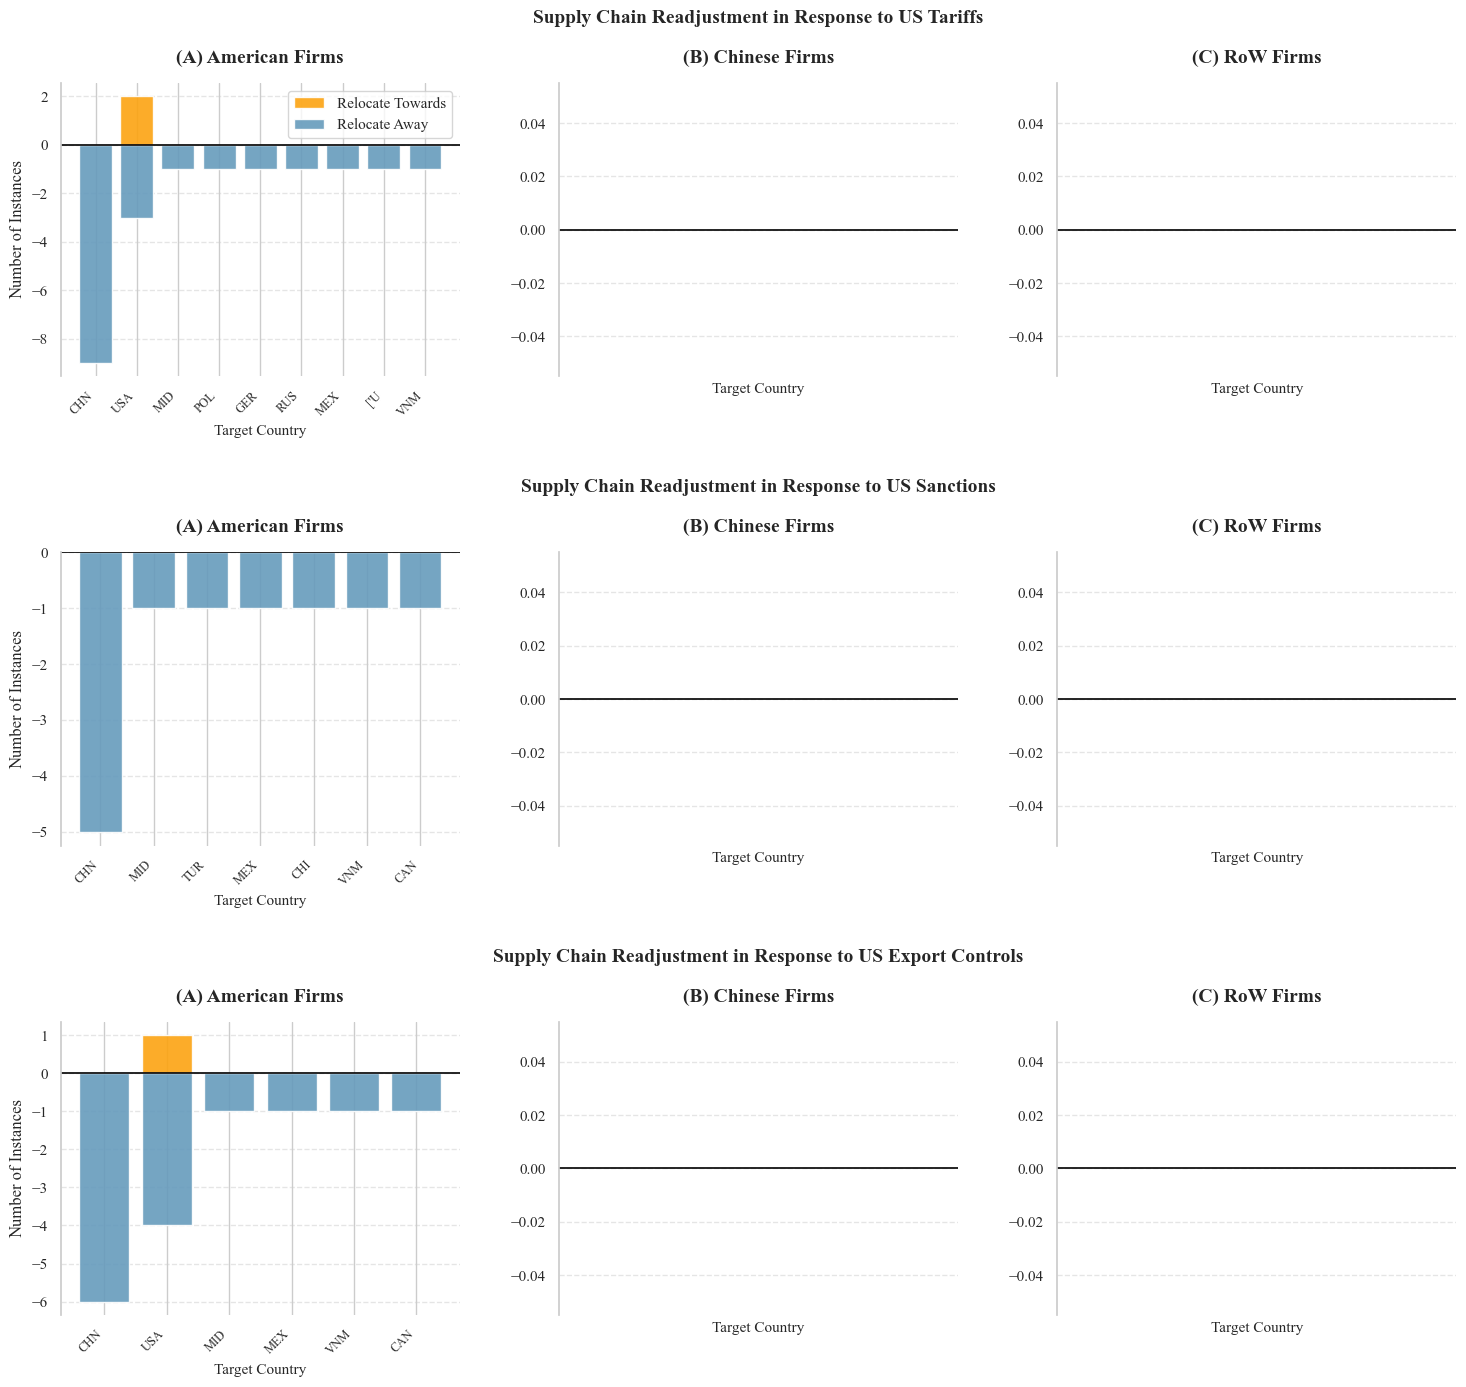

In [28]:
"""
Analyze supply chain readjustments in response to US geoeconomic pressure.

This script categorizes firms into groups (American, Chinese, Rest of World),
extracts data regarding supply chain relocation (towards or away from 
specific countries), standardizes country acronyms, and visualizes the 
net movements in a 3x3 grid of bar charts.
"""

# CACHING AND ALIAS DEFINITIONS
country_cache = {}

us_aliases = {'usa', 'us', 'united states', 'america', 'u.s.', 'u.s.a.'}
chn_aliases = {'china', 'chn', 'prc', 'macau', 'hong kong'}

COUNTRY_STANDARD_MAP = {
    'UNITED STATES': 'USA', 'US': 'USA', 'U.S.': 'USA', 'AMERICA': 'USA',
    'CHINA': 'CHN', 'PRC': 'CHN',
    'MEXICO': 'MEX', 'VIETNAM': 'VNM', 'MALAYSIA': 'MYS', 'INDIA': 'IND',
    'TAIWAN': 'TWN', 'THAILAND': 'THA', 'CANADA': 'CAN', 
    'EUROPEAN UNION': 'EU', 'EUROPE': 'EU', 'RUSSIA': 'RUS',
    'KOREA': 'KOR', 'SOUTH KOREA': 'KOR', 'JAPAN': 'JPN',
    'INDONESIA': 'IDN', 'SINGAPORE': 'SGP', 'BRAZIL': 'BRA',
    'PHILIPPINES': 'PHL', 'UKRAINE': 'UKR', 'BELARUS': 'BLR',
    'TURKEY': 'TUR', 'SWEDEN': 'SWE', 'IRAN': 'IRN'
}


def get_country_from_ticker(ticker):
    """
    Retrieve the home country of a company using its ticker via yfinance.
    
    Args:
        ticker (str): The stock ticker symbol.
        
    Returns:
        str: The country name, defaulting to 'United States' if not found.
    """
    if pd.isna(ticker):
        return 'Unknown'
        
    clean_ticker = str(ticker).strip()
    
    if clean_ticker not in country_cache:
        try:
            stock_info = yf.Ticker(clean_ticker).info
            country_cache[clean_ticker] = stock_info.get(
                'country', 'United States'
            )
        except Exception:
            country_cache[clean_ticker] = 'United States'
            
    return country_cache[clean_ticker]


def get_firm_group(country_name):
    """
    Categorize a country into a macro firm group.
    
    Args:
        country_name (str): The name of the country.
        
    Returns:
        str: 'American Firms', 'Chinese Firms', 'RoW Firms', or 'Unknown'.
    """
    country_lower = str(country_name).lower().strip()
    
    if country_lower in us_aliases:
        return 'American Firms'
    if country_lower in chn_aliases:
        return 'Chinese Firms'
    if country_lower not in ('unknown', 'nan', ''):
        return 'RoW Firms'
        
    return 'Unknown'


def clean_and_split_countries(val):
    """
    Parse, split, and standardize a comma-separated string of countries.
    
    Args:
        val (str): Raw string of countries from the dataset.
        
    Returns:
        list of str: A list of standardized 3-letter country codes.
    """
    if pd.isna(val):
        return []
        
    countries = str(val).split(',')
    standardized_list = []
    
    for country in countries:
        cleaned = country.strip().upper()
        if cleaned:
            # Apply mapping or truncate to 3 letters if not mapped
            standardized = COUNTRY_STANDARD_MAP.get(
                cleaned, 
                cleaned[:3] if len(cleaned) > 3 else cleaned
            )
            standardized_list.append(standardized)
            
    return standardized_list


# DATA ENHANCEMENT
data_merged['firm_country'] = data_merged['ticker'].apply(
    get_country_from_ticker
)
data_merged['Firm Group'] = data_merged['firm_country'].apply(get_firm_group)


# MEASURE CONFIGURATION
# Using the corrected column names to prevent KeyErrors
measures = ['tariffs_effect_any', 'sanctions_effect_any', 'exports_effect_any']

measure_names = {
    'tariffs_effect_any': 'Tariffs',
    'sanctions_effect_any': 'Sanctions',
    'exports_effect_any': 'Export Controls'
}

prefix_map = {
    'tariffs_effect_any': 'tariffs_',
    'sanctions_effect_any': 'sanctions_',
    'exports_effect_any': 'exports_'
}

groups = ['American Firms', 'Chinese Firms', 'RoW Firms']


# PLOTTING SETUP
sns.set_theme(
    style="whitegrid", 
    rc={"font.family": "serif", "font.serif": ["Times New Roman"]}
)
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
plt.subplots_adjust(hspace=0.6, wspace=0.25)


# MAIN VISUALIZATION LOOP
for i, measure_col in enumerate(measures):
    measure_title = measure_names.get(measure_col, measure_col)
    prefix = prefix_map.get(measure_col, "")
    
    if measure_col not in data_merged.columns:
        print(f"Warning: Column {measure_col} not found in dataset.")
        continue
        
    # Filter for active measures
    active_mask = (
        data_merged[measure_col]
        .astype(str).str.strip().str.lower()
        .isin(['1', '1.0', 'true', 'yes', 'y', 't'])
    )
    df_measure = data_merged[active_mask].copy()
    
    # Isolate measures imposed specifically by the US
    col_imposing = f"{prefix}countries_imposing"
    if col_imposing in df_measure.columns:
        def is_us_imposing(val):
            if pd.isna(val):
                return False
            return any(u in str(val).lower() for u in us_aliases)
            
        df_measure = df_measure[df_measure[col_imposing].apply(is_us_imposing)]
        
    col_toward = f"{prefix}countries_supply_chain_adj_towards"
    col_away = f"{prefix}countries_supply_chain_adj_away"
    
    # Plot bars for each firm group
    for j, firm_group in enumerate(groups):
        ax = axes[i, j]
        df_group = df_measure[df_measure['Firm Group'] == firm_group]
        
        counts_toward = {}
        counts_away = {}
        
        # Aggregate relocations towards countries
        if col_toward in df_group.columns:
            for val in df_group[col_toward]:
                for c in clean_and_split_countries(val):
                    counts_toward[c] = counts_toward.get(c, 0) + 1
                    
        # Aggregate relocations away from countries
        if col_away in df_group.columns:
            for val in df_group[col_away]:
                for c in clean_and_split_countries(val):
                    counts_away[c] = counts_away.get(c, 0) + 1
                    
        # Identify top countries involved in the readjustments
        all_countries = list(
            set(list(counts_toward.keys()) + list(counts_away.keys()))
        )
        
        # Sort countries by total activity (towards + away)
        all_countries.sort(
            key=lambda x: (counts_away.get(x, 0) + counts_toward.get(x, 0)), 
            reverse=True
        )
        # Limit to top 15 for readability
        all_countries = all_countries[:15]
        
        x_vals = np.arange(len(all_countries))
        y_toward = [counts_toward.get(c, 0) for c in all_countries]
        y_away = [-counts_away.get(c, 0) for c in all_countries]
        
        # Draw mirrored bar charts
        ax.bar(
            x_vals, y_toward, color='#fca311', 
            label='Relocate Towards', alpha=0.9
        )
        ax.bar(
            x_vals, y_away, color='#669bbc', 
            label='Relocate Away', alpha=0.9
        )
        
        ax.axhline(0, color='black', linewidth=1.2)
        ax.set_xticks(x_vals)
        ax.set_xticklabels(all_countries, rotation=45, ha='right', fontsize=9)
        ax.spines[['top', 'right', 'bottom']].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Dynamic title assignment matching the academic paper layout
        group_letter = chr(65 + j)  # Converts 0,1,2 to A,B,C
        if i == 0 and j == 1:
            ax.set_title(
                f"Supply Chain Readjustment in Response to US {measure_title}\n\n"
                f"({group_letter}) {firm_group}", 
                fontsize=14, pad=15, fontweight='bold'
            )
        elif j == 1:
            ax.set_title(
                f"Supply Chain Readjustment in Response to US {measure_title}\n\n"
                f"({group_letter}) {firm_group}", 
                fontsize=14, pad=15, fontweight='bold'
            )
        else:
            ax.set_title(
                f"({group_letter}) {firm_group}", 
                fontsize=14, pad=15, fontweight='bold'
            )
            
        if j == 0:
            ax.set_ylabel("Number of Instances", fontsize=12)
            
        ax.set_xlabel("Target Country", fontsize=11)
        
        if i == 0 and j == 0:
            ax.legend(loc='upper right', frameon=True)

# Export and display
os.makedirs("outputs", exist_ok=True)
out_path = "outputs/supply_chain_readjustment.png"

try:
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Success: Figure exported locally to '{out_path}'.")
except Exception as e:
    print(f"Error saving the plot: {e}")

plt.show()

### Note on firm group distribution

As with the previous analysis, there is a visible disparity in the volume of reported supply chain readjustments (the y-axis "Number of Instances") between **American Firms** and the **Chinese / RoW (Rest of World) Firms** panels.

This volumetric imbalance is a direct artifact of the underlying text corpus. Because our current dataset is exclusively derived from **S&P 500 earnings call transcripts**, the sample is inherently skewed towards US-headquartered multinationals. Consequently, while we capture a dense volume of supply chain realignments for American firms reacting to US geoeconomic policies, the sample size for foreign entities (Chinese and RoW firms) that happen to be captured within this specific US-centric index is naturally much smaller.

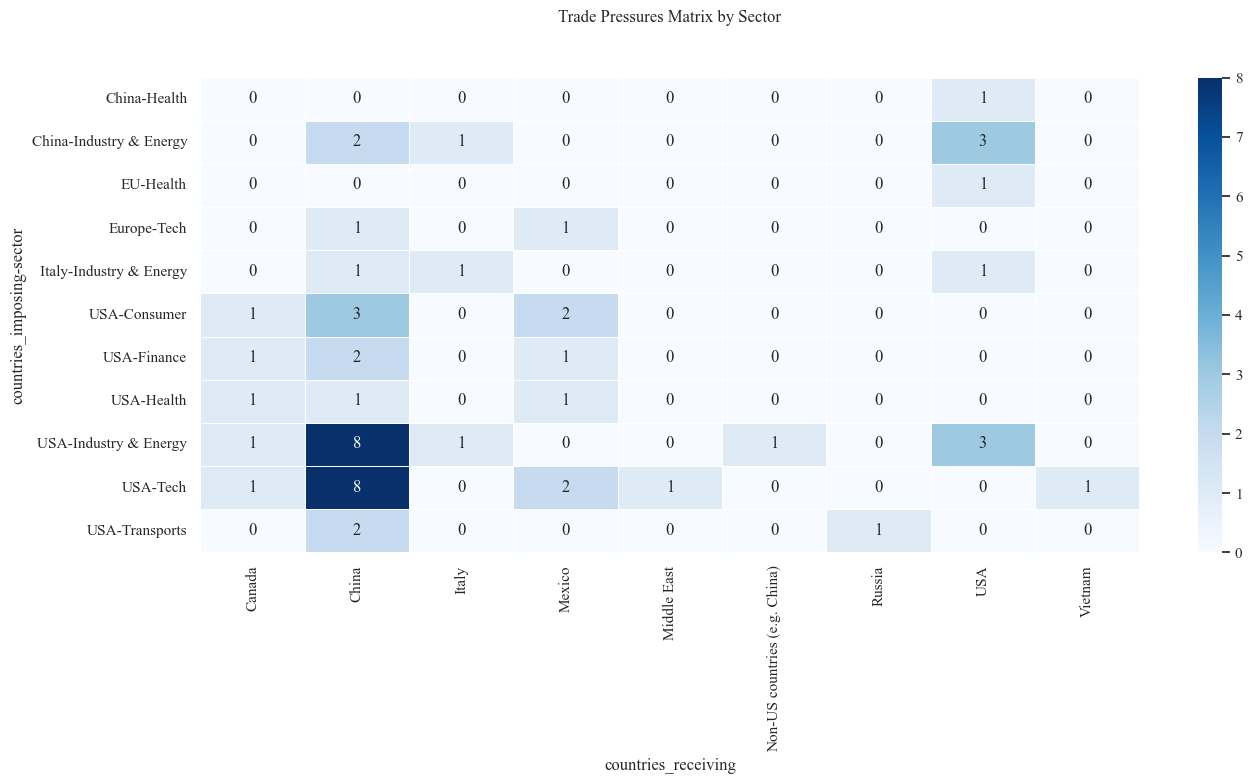

In [29]:
"""
Analyze and visualize trade pressures between imposing and receiving countries.

This script processes merged dataset columns relating to tariffs, export 
controls, and sanctions. It extracts the directional flow of these measures,
standardizes the data, and generates a heatmap representing the density of 
trade pressures across different sectors.
"""

data_working = data_merged.copy()
all_pressures = []

prefix_map = {
    'tariffs_effect_any': 'tariffs_',
    'effect_any': '',
    'export_controls_any': 'exports_',
    'sanctions_any': 'sanctions_'
}

for measure_col, prefix in prefix_map.items():
    if measure_col in data_working.columns:
        col_imp = f"{prefix}countries_imposing"
        col_rec = f"{prefix}countries_receiving"
        
        if col_imp in data_working.columns and col_rec in data_working.columns:
            temp_df = data_working[
                data_working[measure_col] == 1
            ][[col_imp, col_rec, 'sector']].copy()
            
            if not temp_df.empty:
                temp_df.columns = ['countries_imposing', 'countries_receiving', 'sector']
                all_pressures.append(temp_df)

if not all_pressures:
    print("Warning: No applicable trade pressure data found in the dataset.")
else:
    df_matrix = pd.concat(all_pressures, ignore_index=True)
    
    df_matrix = df_matrix.replace(['', 'nan', 'NaN', 'None'], pd.NA).dropna()

    df_matrix['countries_imposing'] = df_matrix['countries_imposing'].astype(str).str.split(',')
    df_matrix['countries_receiving'] = df_matrix['countries_receiving'].astype(str).str.split(',')
    
    df_matrix = df_matrix.explode('countries_imposing').explode('countries_receiving')
    
    df_matrix = df_matrix.reset_index(drop=True)

    for col in ['countries_imposing', 'countries_receiving', 'sector']:
        df_matrix[col] = df_matrix[col].astype(str).str.strip()
        df_matrix = df_matrix[df_matrix[col] != 'nan']
        df_matrix = df_matrix[df_matrix[col] != '']

    if df_matrix.empty:
        print("Warning: Data matrix is empty after cleaning and filtering.")
    else:
        matrix = pd.crosstab(
            index=[df_matrix['countries_imposing'], df_matrix['sector']],
            columns=df_matrix['countries_receiving']
        )

        if matrix.empty:
            print("Warning: Cross-tabulation resulted in an empty matrix.")
        else:
            plt.figure(figsize=(14, max(8, len(matrix) * 0.45)))
            sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", linewidths=.5)
            plt.title("Trade Pressures Matrix by Sector", pad=40)
            plt.tight_layout()
            plt.show()

### Trades pressure matrix

In the future, we would like to analyze these geoeconomic pressures more in detail with roundabout models, which rely on similar matrices.

## Checking the integrity of our scraped sample

As the data we obtained from scraping has attrition and comes from very different sectors, we need to check that we can derive analyses from time trends and sectorial tendancies. Thus, we need to check the stability of the sample over time and sectors.

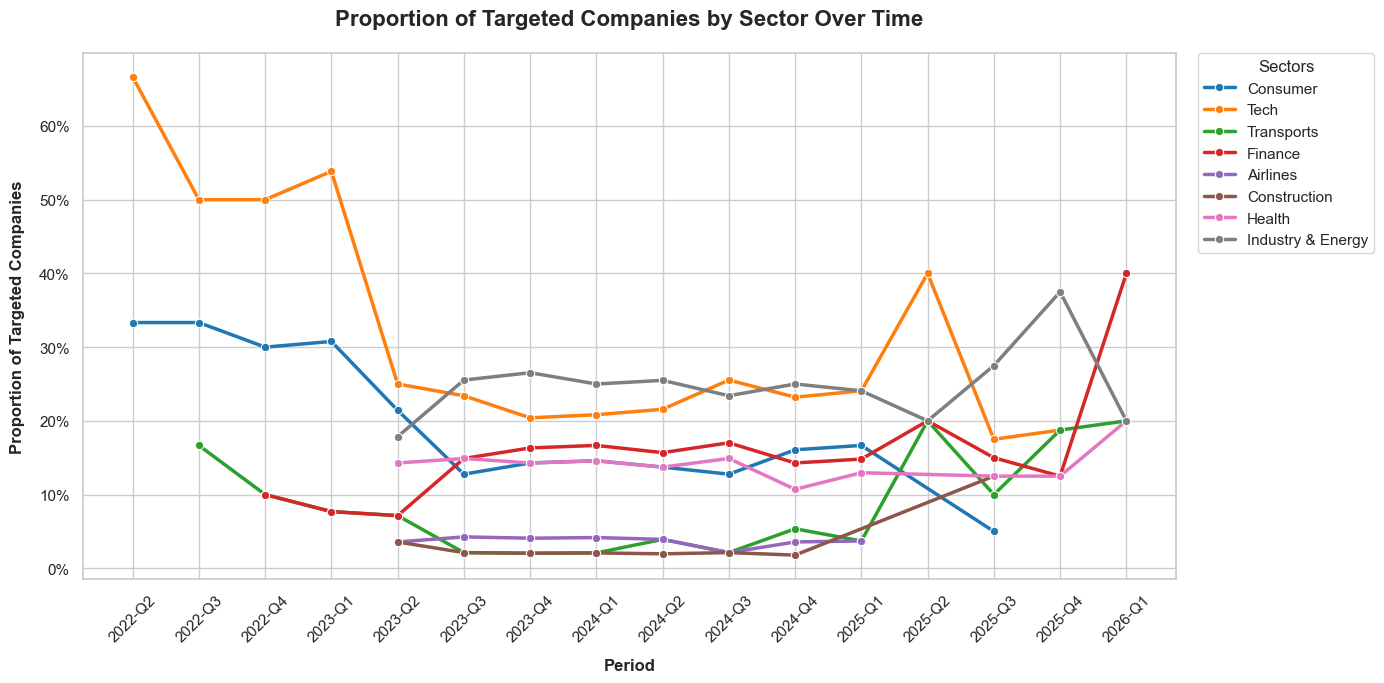

In [31]:
def plot_sector_evolution(data_merged):
    """
    Plot the proportion of targeted companies by sector over time.

    Group the dataset by temporal period and sector to calculate the relative 
    share of unique companies affected compared to the total number of companies 
    per period. Generate, save, and display a line plot of this evolution.

    Args:
        data_merged (pd.DataFrame): The dataset containing 'year', 'quarter', 
            'sector', and 'company' columns.

    Returns:
        None
    """
    df_time = data_merged.copy()

    df_time['period'] = df_time['year'].astype(str) + '-' + df_time['quarter'].astype(str)

    evolution_sector = df_time.groupby(['period', 'sector'])['company'].nunique().reset_index(name='sector_count')
    evolution_total = df_time.groupby('period')['company'].nunique().reset_index(name='total_count')

    evolution = pd.merge(evolution_sector, evolution_total, on='period')
    evolution['ratio'] = evolution['sector_count'] / evolution['total_count']
    evolution = evolution.sort_values('period')

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=evolution,
        x='period',
        y='ratio',
        hue='sector',
        marker='o',
        linewidth=2.5,
        palette="tab10"
    )

    plt.title("Proportion of Targeted Companies by Sector Over Time", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Period", fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel("Proportion of Targeted Companies", fontsize=12, fontweight='bold', labelpad=10)

    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.xticks(rotation=45)
    plt.legend(title="Sectors", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.savefig("evolution_sectors.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_sector_evolution(data_merged)

Analyzed periods for the sample: ['2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4', '2026-Q1']



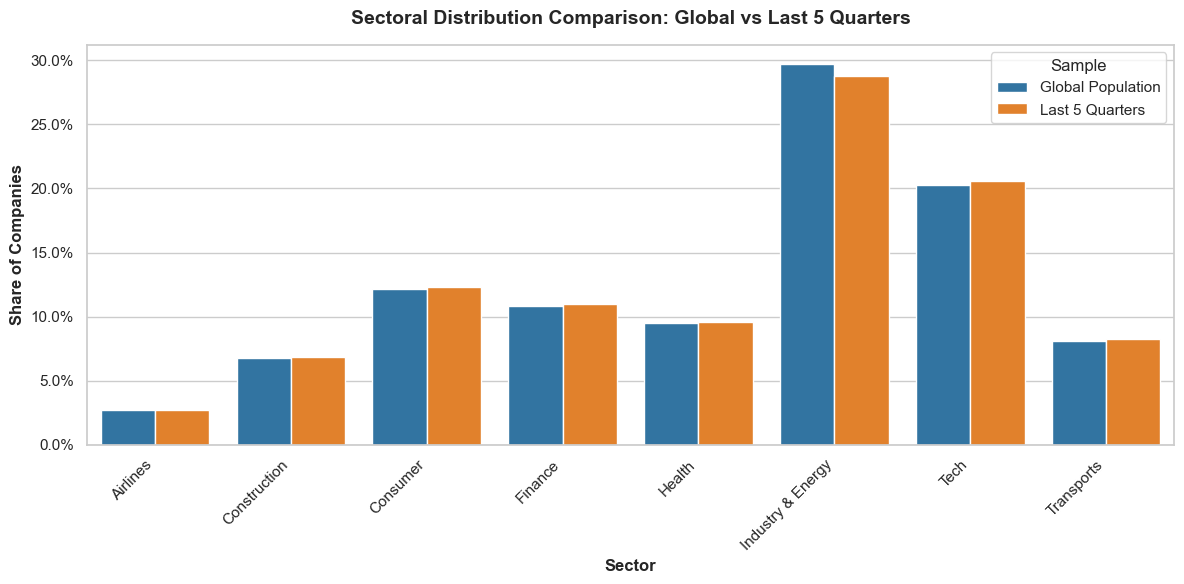

--------------------------------------------------
REPRESENTATIVENESS TEST RESULTS (Chi-Square)
--------------------------------------------------
Global population size: 74 companies
Recent sample size: 73 companies

Chi-Square Statistic: 0.0324
P-value: 1.0000

CONCLUSION: The p-value is > 0.05.
No statistically significant difference detected.
=> The last 5 quarters are a REPRESENTATIVE sample of the global population.


In [34]:
def evaluate_sample_representativeness(data_merged):
    """
    Evaluate the statistical representativeness of the recent sample against the global population.

    Extract unique companies and their sector distributions for the entire dataset 
    and the last five available quarters. Generate a comparative bar chart and 
    perform a Chi-Square goodness-of-fit test to determine if the recent sample 
    significantly deviates from the historical global sector distribution.

    Args:
        data_merged (pd.DataFrame): The dataset containing 'year', 'quarter', 
            'sector', and 'company' columns.

    Returns:
        None
    """
    df_time = data_merged.copy()
    
    df_time['period'] = (
        df_time['year'].astype(str).str.replace('.0', '', regex=False) + 
        '-' + 
        df_time['quarter'].astype(str).str.replace('.0', '', regex=False)
    )
    
    unique_periods = [p for p in df_time['period'].unique() if isinstance(p, str) and p != 'nan-nan']
    sorted_periods = sorted(unique_periods)
    last_five_quarters = sorted_periods[-5:]
    
    print(f"Analyzed periods for the sample: {last_five_quarters}\n")
    
    total_population = df_time.drop_duplicates(subset=['company'])
    total_companies_count = len(total_population)
    total_distribution = total_population['sector'].value_counts(normalize=True).sort_index()
    
    df_recent = df_time[df_time['period'].isin(last_five_quarters)]
    recent_population = df_recent.drop_duplicates(subset=['company'])
    recent_companies_count = len(recent_population)
    recent_distribution = recent_population['sector'].value_counts(normalize=True).sort_index()
    
    common_sectors = total_distribution.index.union(recent_distribution.index)
    total_distribution = total_distribution.reindex(common_sectors, fill_value=0)
    recent_distribution = recent_distribution.reindex(common_sectors, fill_value=0)
    
    df_plot_total = pd.DataFrame({
        'Sector': common_sectors, 
        'Proportion': total_distribution, 
        'Group': 'Global Population'
    })
    df_plot_recent = pd.DataFrame({
        'Sector': common_sectors, 
        'Proportion': recent_distribution, 
        'Group': 'Last 5 Quarters'
    })
    df_comparison = pd.concat([df_plot_total, df_plot_recent])
    
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    sns.barplot(
        data=df_comparison, 
        x='Sector', 
        y='Proportion', 
        hue='Group',
        palette=['#1f77b4', '#ff7f0e']
    )
    
    plt.title("Sectoral Distribution Comparison: Global vs Last 5 Quarters", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Share of Companies", fontweight='bold')
    plt.xlabel("Sector", fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.legend(title="Sample", loc='upper right')
    plt.tight_layout()
    plt.show()
    
    observed_frequencies = recent_population['sector'].value_counts().reindex(common_sectors, fill_value=0)
    expected_frequencies = total_distribution * recent_companies_count
    
    chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)
    
    print("-" * 50)
    print("REPRESENTATIVENESS TEST RESULTS (Chi-Square)")
    print("-" * 50)
    print(f"Global population size: {total_companies_count} companies")
    print(f"Recent sample size: {recent_companies_count} companies\n")
    print(f"Chi-Square Statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_value:.4f}\n")
    
    if p_value > 0.05:
        print("CONCLUSION: The p-value is > 0.05.")
        print("No statistically significant difference detected.")
        print("=> The last 5 quarters are a REPRESENTATIVE sample of the global population.")
    else:
        print("CONCLUSION: The p-value is <= 0.05.")
        print("A statistically significant difference is detected.")
        print("=> The last 5 quarters are NOT REPRESENTATIVE of the global population (sectoral over/under-representation).")

evaluate_sample_representativeness(data_merged)

------------------------------------------------------------
SUMMARY OF REPRESENTATIVENESS BY QUARTER
------------------------------------------------------------
 Period  Company_Count  P_Value Representative
2022-Q2              3 0.503088            Yes
2022-Q3              6 0.257208            Yes
2022-Q4             10 0.104178            Yes
2023-Q1             13 0.015133             No
2023-Q2             28 0.637744            Yes
2023-Q3             47 0.461277            Yes
2023-Q4             49 0.416639            Yes
2024-Q1             48 0.375296            Yes
2024-Q2             51 0.578203            Yes
2024-Q3             47 0.327865            Yes
2024-Q4             56 0.683099            Yes
2025-Q1             54 0.289802            Yes
2025-Q2              5 0.787112            Yes
2025-Q3             40 0.521653            Yes
2025-Q4             16 0.512475            Yes
2026-Q1              5 0.364120            Yes
--------------------------------------

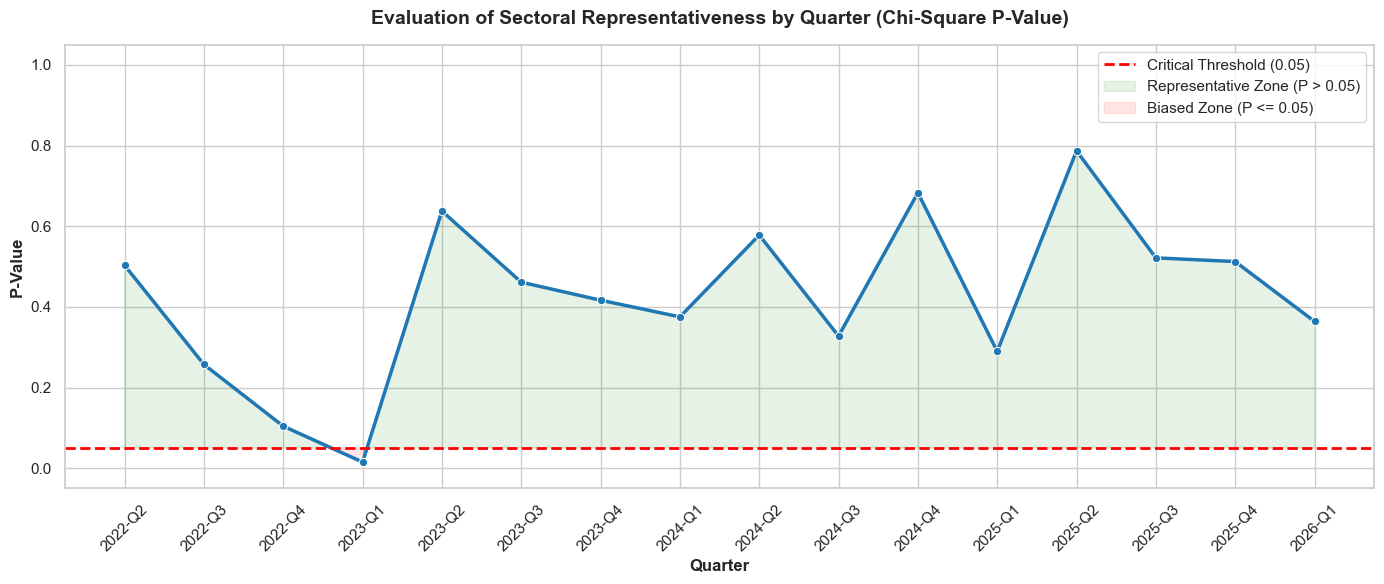

In [36]:
def track_quarterly_representativeness(data_merged):
    """
    Evaluate and visualize the sectoral representativeness of each quarter.

    Calculate the Chi-Square p-value for each quarter to determine if its 
    sectoral distribution significantly deviates from the global dataset 
    population. Generate a time-series plot highlighting representative 
    and biased periods based on a 0.05 significance threshold.

    Args:
        data_merged (pd.DataFrame): The dataset containing 'year', 'quarter', 
            'sector', and 'company' columns.

    Returns:
        None
    """
    df_rep = data_merged.copy()
    
    df_rep['period'] = (
        df_rep['year'].astype(str).str.replace('.0', '', regex=False) + 
        '-' + 
        df_rep['quarter'].astype(str).str.replace('.0', '', regex=False)
    )
    
    unique_periods = [
        p for p in df_rep['period'].unique() 
        if isinstance(p, str) and 'nan' not in p
    ]
    sorted_periods = sorted(unique_periods)
    
    total_population = df_rep.drop_duplicates(subset=['company'])
    total_distribution = total_population['sector'].value_counts(normalize=True).sort_index()
    reference_sectors = total_distribution.index
    
    test_results = []
    
    for period in sorted_periods:
        df_period = df_rep[df_rep['period'] == period]
        period_population = df_period.drop_duplicates(subset=['company'])
        period_total = len(period_population)
        
        if period_total == 0:
            continue
            
        observed_frequencies = period_population['sector'].value_counts().reindex(reference_sectors, fill_value=0)
        expected_frequencies = total_distribution * period_total
        
        chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)
        
        test_results.append({
            'Period': period,
            'Company_Count': period_total,
            'Chi2_Stat': chi2_stat,
            'P_Value': p_value,
            'Representative': 'Yes' if p_value > 0.05 else 'No'
        })
        
    df_results = pd.DataFrame(test_results)
    
    print("-" * 60)
    print("SUMMARY OF REPRESENTATIVENESS BY QUARTER")
    print("-" * 60)
    print(df_results[['Period', 'Company_Count', 'P_Value', 'Representative']].to_string(index=False))
    print("-" * 60)
    
    plt.figure(figsize=(14, 6))
    sns.set_theme(style="whitegrid")
    
    sns.lineplot(
        data=df_results, 
        x='Period', 
        y='P_Value', 
        marker='o',
        linewidth=2.5,
        color='#1f77b4'
    )
    
    plt.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Critical Threshold (0.05)')
    
    plt.fill_between(
        df_results['Period'], 
        df_results['P_Value'], 
        0.05, 
        where=(df_results['P_Value'] > 0.05), 
        interpolate=True, 
        color='green', 
        alpha=0.1, 
        label='Representative Zone (P > 0.05)'
    )
    plt.fill_between(
        df_results['Period'], 
        df_results['P_Value'], 
        0.05, 
        where=(df_results['P_Value'] <= 0.05), 
        interpolate=True, 
        color='red', 
        alpha=0.1, 
        label='Biased Zone (P <= 0.05)'
    )
    
    plt.title("Evaluation of Sectoral Representativeness by Quarter (Chi-Square P-Value)", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("P-Value", fontweight='bold')
    plt.xlabel("Quarter", fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylim(-0.05, 1.05)
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig("representativeness_over_time.png", dpi=300, bbox_inches='tight')
    plt.show()

track_quarterly_representativeness(data_merged)

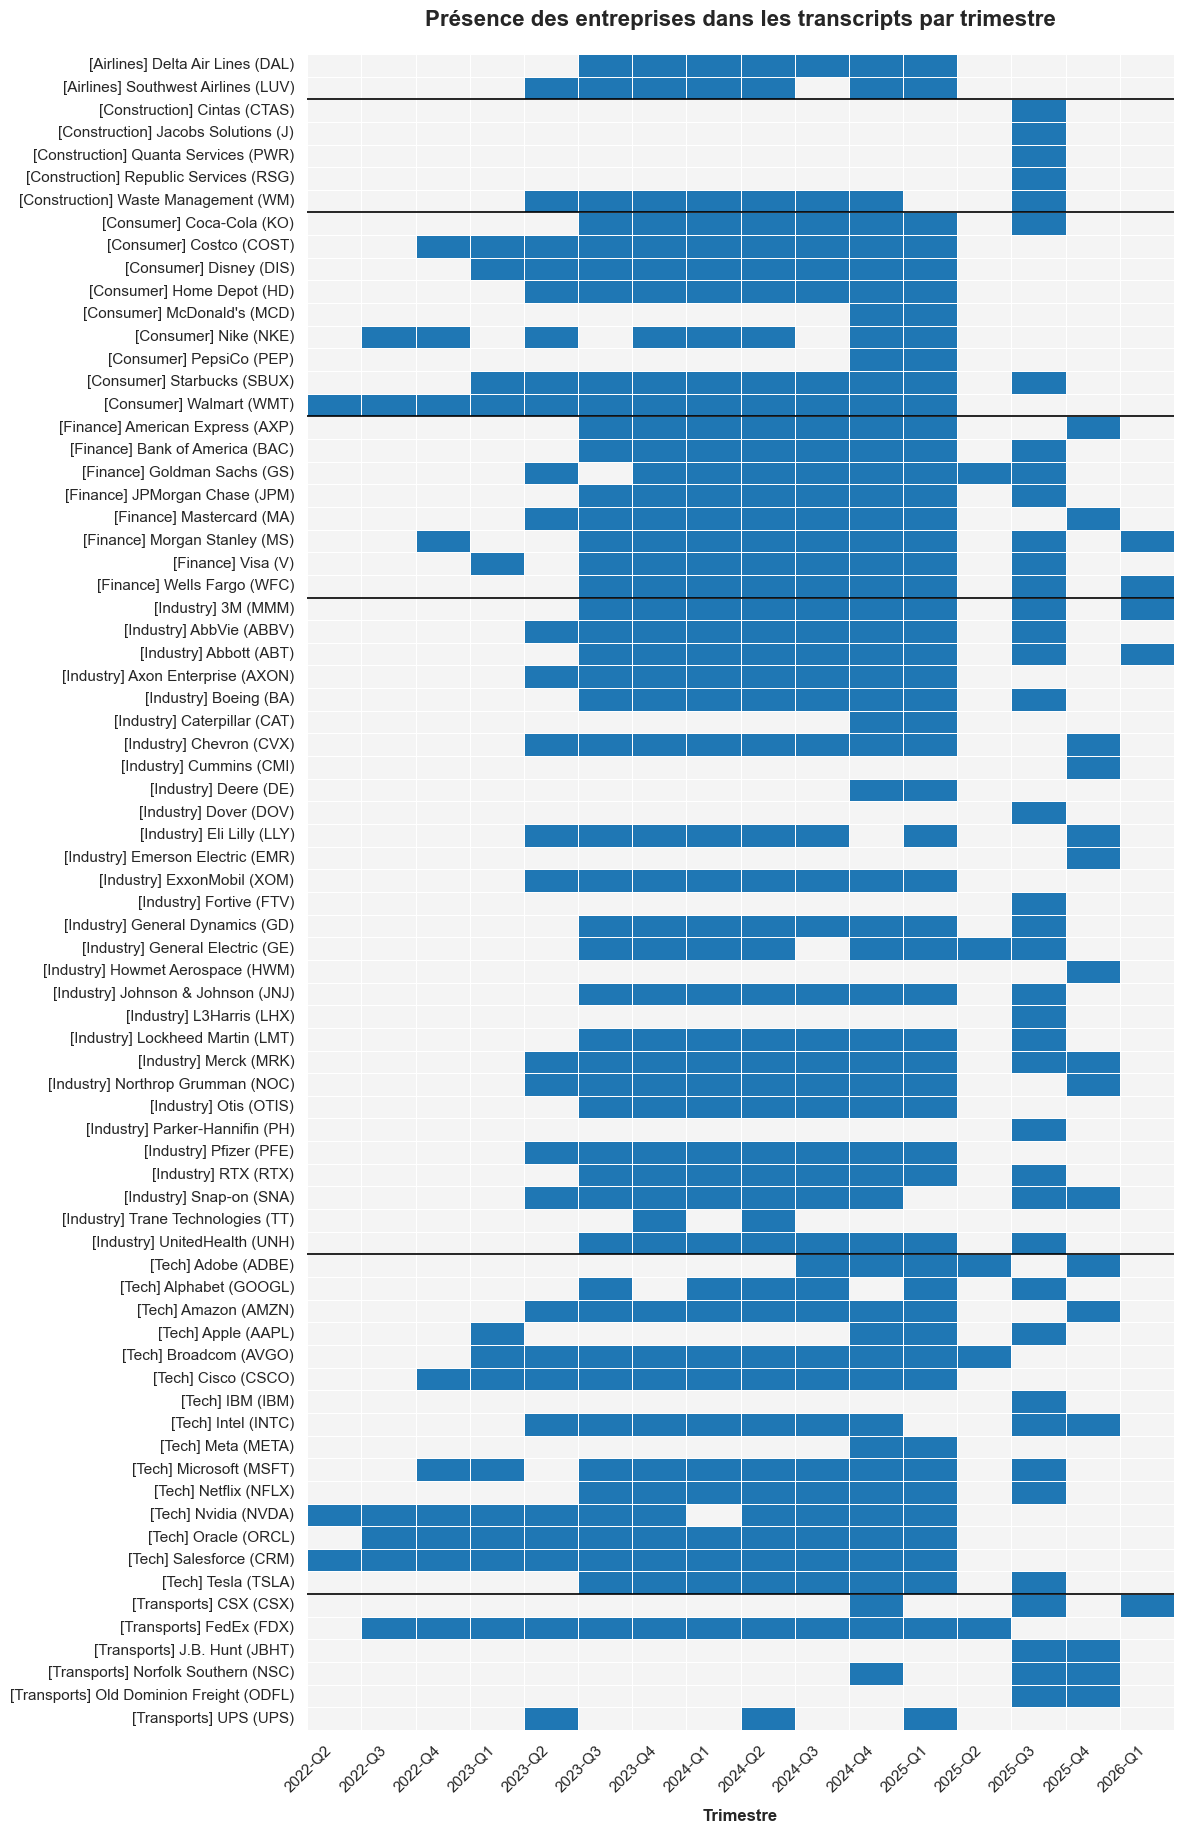

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_vis = data_merged_2.copy()

# 1. Création de la variable temporelle
df_vis['period'] = df_vis['year'].astype(str) + '-' + df_vis['quarter'].astype(str)

# 2. Création de la matrice de présence
# On garde une seule ligne par entreprise et par trimestre
presence = df_vis.drop_duplicates(subset=['company', 'sector', 'period']).copy()
presence['present'] = 1

# On pivote pour avoir les entreprises en lignes et les trimestres en colonnes
matrix = presence.pivot_table(
    index=['sector', 'company'], 
    columns='period', 
    values='present', 
    fill_value=0
)

# 3. Tri et formatage pour un affichage propre
# Le tri par secteur regroupe visuellement les entreprises similaires
matrix = matrix.sort_index(level=['sector', 'company'])

# On formate les étiquettes de l'axe Y pour afficher le secteur et l'entreprise
matrix.index = [f"[{sec}] {comp}" for sec, comp in matrix.index]

# 4. Tracé du graphique
# La hauteur s'adapte dynamiquement au nombre d'entreprises
plt.figure(figsize=(12, max(8, len(matrix) * 0.25)))
sns.set_theme(style="white")

# Création d'une palette binaire : gris clair (absent, 0) et bleu foncé (présent, 1)
cmap = sns.color_palette(["#f4f4f4", "#1f77b4"])

ax = sns.heatmap(
    matrix, 
    cmap=cmap, 
    linewidths=0.5,       # Ajoute un léger quadrillage
    linecolor='white', 
    cbar=False            # On retire la légende de couleur inutile (c'est du binaire)
)

plt.title("Présence des entreprises dans les transcripts par trimestre", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Trimestre", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("", fontsize=12) # L'axe Y est assez évident, pas besoin de label

# Amélioration de la lisibilité de l'axe X
plt.xticks(rotation=45, ha='right')

# Ajout de lignes horizontales pour séparer visuellement les secteurs
secteurs = [label.split("] ")[0] for label in matrix.index]
for i in range(1, len(secteurs)):
    if secteurs[i] != secteurs[i-1]:
        ax.axhline(i, color='black', linewidth=1.2)

plt.tight_layout()
plt.savefig("heatmap_presence.png", dpi=300)
plt.show()


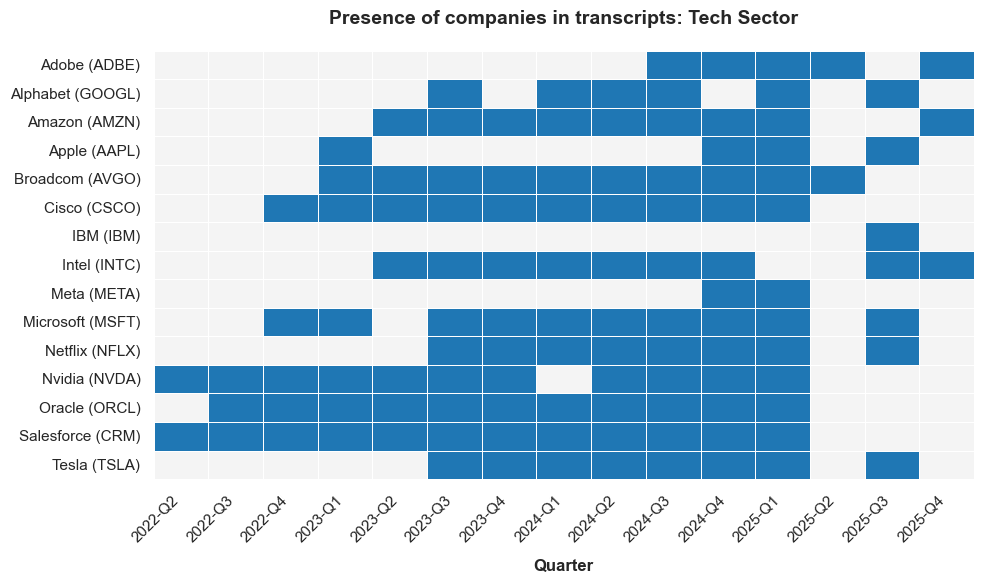

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_vis = data_merged_2.copy()

df_vis = df_vis[df_vis['sector'].str.contains('Tech', na=False, case=False)]

df_vis['period'] = df_vis['year'].astype(str) + '-' + df_vis['quarter'].astype(str)

presence = df_vis.drop_duplicates(subset=['company', 'period']).copy()
presence['present'] = 1

matrix = presence.pivot_table(
    index='company', 
    columns='period', 
    values='present', 
    fill_value=0
)

matrix = matrix.sort_index()

plt.figure(figsize=(10, max(6, len(matrix) * 0.35)))
sns.set_theme(style="white")

cmap = sns.color_palette(["#f4f4f4", "#1f77b4"])

ax = sns.heatmap(
    matrix, 
    cmap=cmap, 
    linewidths=0.5,       
    linecolor='white', 
    cbar=False            
)

plt.title("Presence of companies in transcripts: Tech Sector", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Quarter", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("", fontsize=12) 

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("heatmap_presence_tech.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd

# 1. Chargement et nettoyage des données temporelles
df_temp = df.dropna(subset=['year', 'quarter']).copy()
df_temp['year'] = df_temp['year'].astype(int)

# 2. Comptage des observations par année et trimestre
distribution = df_temp.groupby(['year', 'quarter']).size().reset_index(name='Count')

# 3. Pivot pour obtenir le format horizontal (Multi-index en colonnes)
table_3 = distribution.set_index(['year', 'quarter']).T

# Affichage
print("Table 3: Temporal Distribution of Observations")
print(table_3)

Table 3: Temporal Distribution of Observations
year    2022        2023             2024             2025            2026
quarter   Q2 Q3  Q4   Q1  Q2  Q3  Q4   Q1  Q2  Q3  Q4   Q1 Q2  Q3  Q4   Q1
Count      3  6  10   13  28  47  49   48  51  47  59   54  5  43  16    5


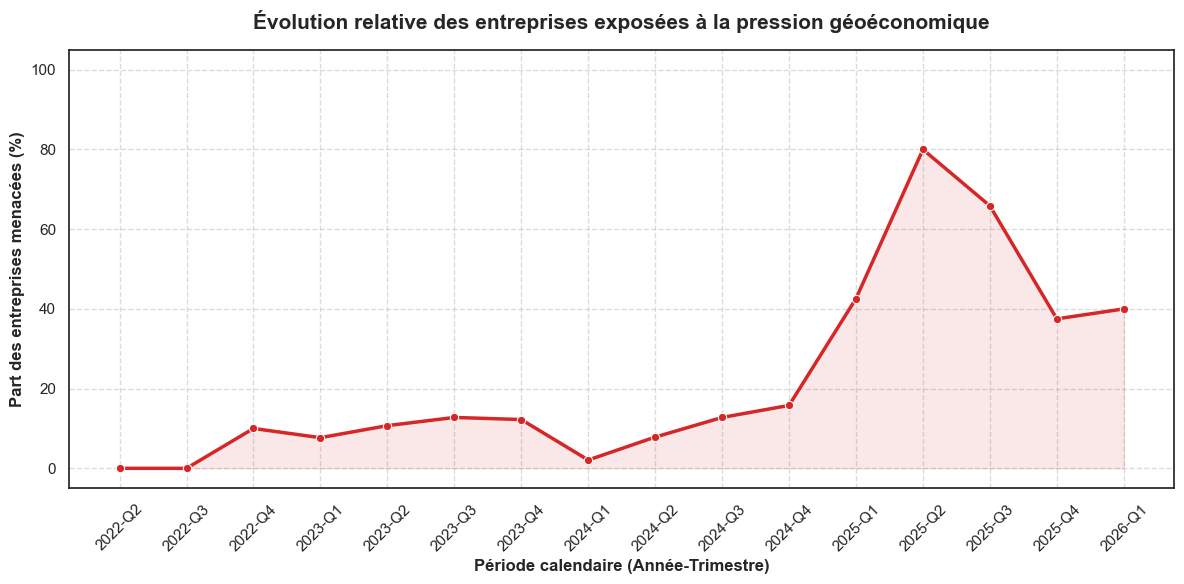

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PRÉPARATION DES DONNÉES TEMPORELLES ---
# Assurez-vous que 'year' et 'quarter' sont bien définis dans votre df (ex: df = data)
df = data.copy() # On travaille sur la base nettoyée
df['period'] = df['year'].astype(str) + '-' + df['quarter'].astype(str)

# Créer une colonne binaire indiquant si une entreprise est "menacée"
# CORRECTION : Utilisation des noms de colonnes validés par Mistral
df['is_threatened'] = df[['tariffs_effect_any', 'exports_effect_any', 'sanctions_effect_any']].apply(
    lambda x: x.astype(str).str.lower().isin(['1', '1.0', 'true', 'yes', 'y', 't']).any(), axis=1
)

# --- 2. CALCUL DE L'ÉVOLUTION RELATIVE ---
# Calcul du nombre d'entreprises menacées par trimestre / Total par trimestre
df_evolution = df.groupby('period')['is_threatened'].agg(['sum', 'count'])
df_evolution['relative_share'] = df_evolution['sum'] / df_evolution['count']

# Convertir en pourcentage pour l'affichage
df_evolution['relative_share_pct'] = df_evolution['relative_share'] * 100

# --- 3. VISUALISATION ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_evolution, x=df_evolution.index, y='relative_share_pct', marker='o', linewidth=2.5, color='#d62728')
plt.ylabel("Part des entreprises menacées (%)", fontweight='bold')
plt.title("Évolution relative des entreprises exposées à la pression géoéconomique", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Période calendaire (Année-Trimestre)", fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-5, 105) # Pour bien voir l'échelle de 0 à 100%

# Remplissage sous la courbe pour le style
plt.fill_between(df_evolution.index, df_evolution['relative_share_pct'], color='#d62728', alpha=0.1)

plt.tight_layout()
plt.savefig("evolution_entreprises_pct.png", dpi=300)
plt.show()

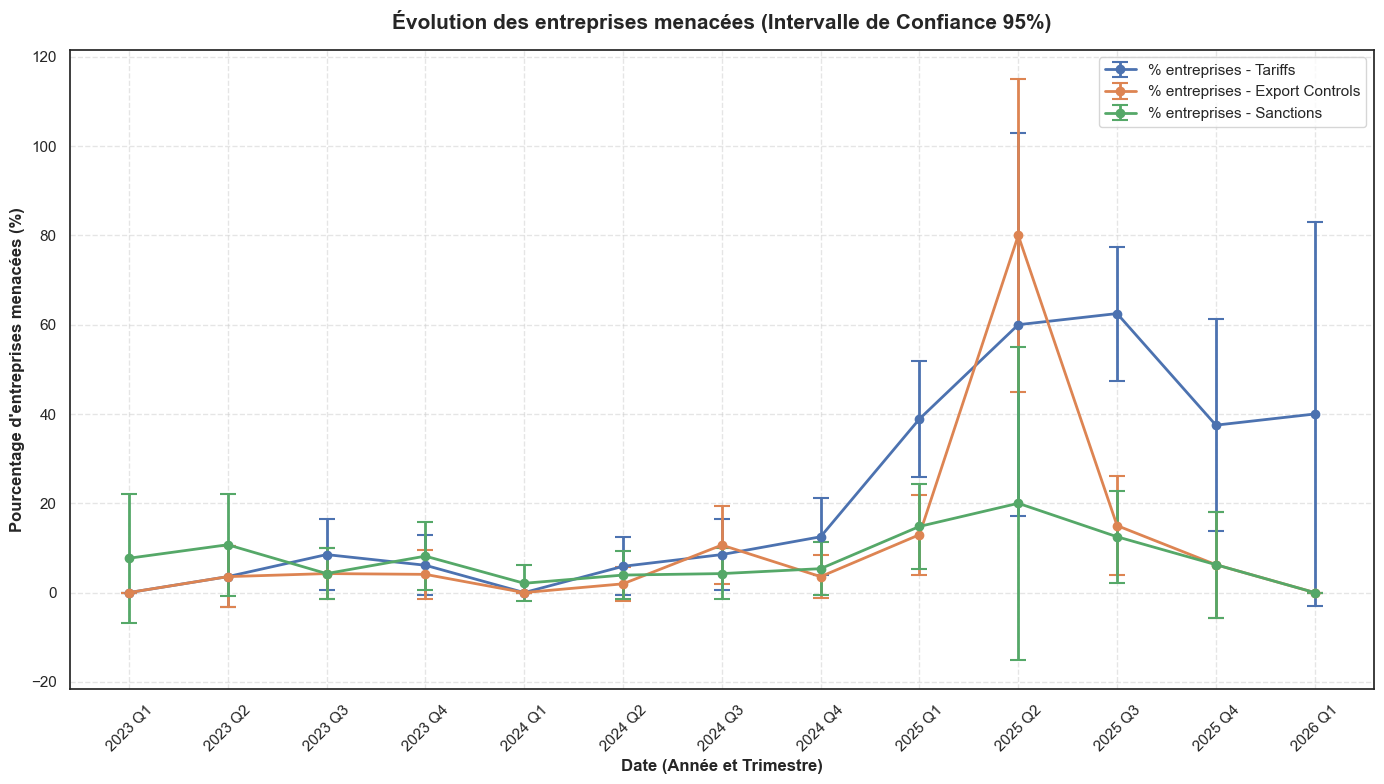

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = df.copy()

# LES BONS NOMS DE COLONNES
measures = ['tariffs_effect_any', 'exports_effect_any', 'sanctions_effect_any']

# Pour avoir une belle légende sur le graphique
labels_propres = {
    'tariffs_effect_any': 'Tariffs',
    'exports_effect_any': 'Export Controls',
    'sanctions_effect_any': 'Sanctions'
}

# à partir de 2023
data = data[data['year'] >= 2023]

plt.figure(figsize=(14, 8))

for measure in measures:
    # On groupe par année et par trimestre (qui est déjà une chaîne "Q1", "Q2", etc.)
    grouped = data.groupby(['year', 'quarter'])
    
    # Calcul de la proportion (p) et du nombre d'entreprises uniques (n)
    stats_sum = grouped[measure].sum()
    n = grouped['company'].nunique()
    
    p = stats_sum / n
    y = p * 100
    
    # Calcul de l'erreur type (Standard Error) pour une proportion
    se = np.sqrt((p * (1 - p)) / n)
    
    # Marge d'erreur à 95% (1.96 * SE) convertie en %
    ci_margin = 1.96 * se * 100
    
    # Préparation des étiquettes de l'axe X (Année Trimestre)
    x_labels = [f"{year} {quarter}" for year, quarter in y.index]
    x_range = range(len(x_labels))
    
    # Tracé avec moustaches (error bars)
    plt.errorbar(x_range, 
                 y.values, 
                 yerr=ci_margin,     # Taille de la moustache
                 fmt='-o',           # Ligne (-) et points (o)
                 linewidth=2, 
                 capsize=6,          # Largeur de la barre horizontale de la moustache
                 capthick=1.5,       # Épaisseur de la barre de la moustache
                 label=f'% entreprises - {labels_propres[measure]}') # Légende propre

# Configuration des axes et du titre
plt.xticks(x_range, x_labels, rotation=45)
plt.xlabel('Date (Année et Trimestre)', fontweight='bold')
plt.ylabel("Pourcentage d'entreprises menacées (%)", fontweight='bold')
plt.title("Évolution des entreprises menacées (Intervalle de Confiance 95%)", fontsize=15, fontweight='bold', pad=15)

# Ajout d'une grille légère et de la légende
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig('evolution_entreprises_moustaches_str.png', dpi=300)
plt.show()

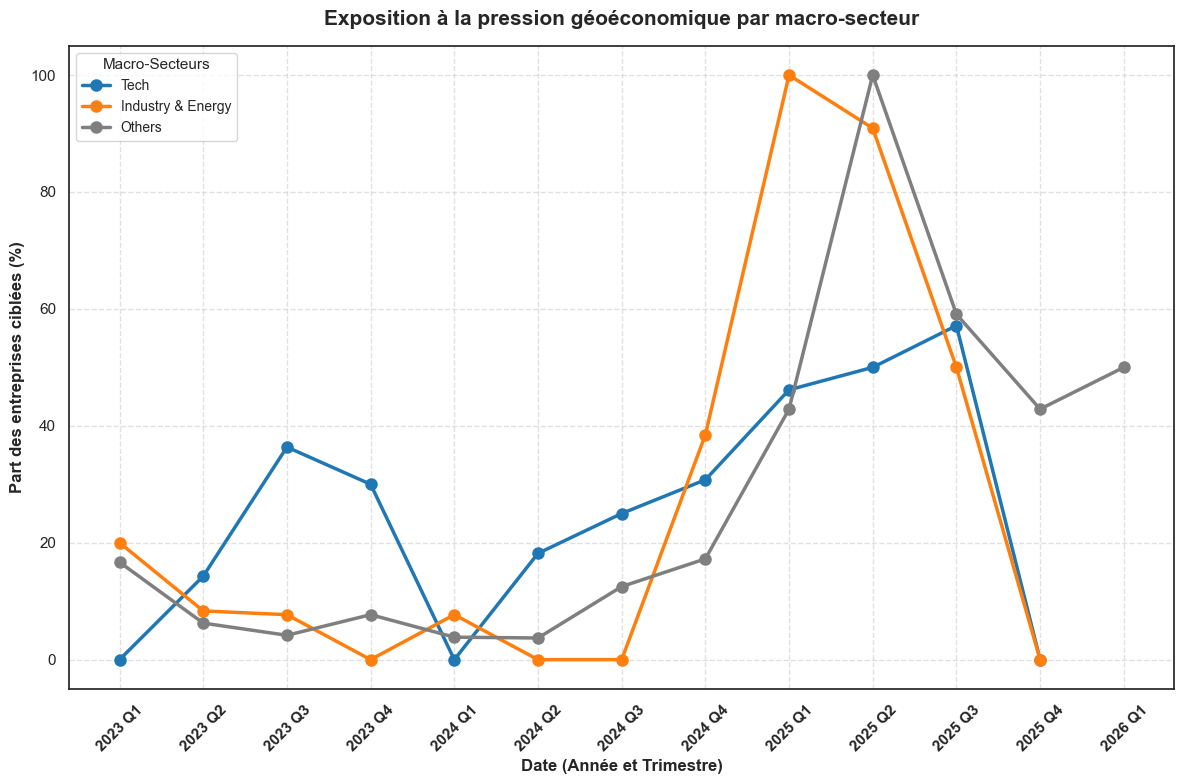

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. On suppose que 'data' est ton dataframe FINAL (celui qui contient déjà la colonne 'sector')
# Si ce n'est pas le cas, assure-toi d'utiliser la variable de ton script précédent qui contient le merge
df_graph = data.copy()

# 2. RECRÉATION DE LA VARIABLE GLOBALE "GEOECONOMIC_ANY"
# Une entreprise est menacée si l'une des trois politiques est à 1 ou True
df_graph['geoeconomic_any'] = df_graph[['tariffs_effect_any', 'exports_effect_any', 'sanctions_effect_any']].apply(
    lambda x: x.astype(str).str.lower().isin(['1', '1.0', 'true', 'yes', 'y', 't']).any(), axis=1
)

# 3. CRÉATION DU GROUPE SECTORIEL
df_graph['sector_grouped'] = df_graph['sector'].apply(
    lambda x: x if x in ['Tech', 'Industry & Energy'] else 'Others'
)

# 4. PRÉPARATION DU GRAPHIQUE
sectors_to_plot = ['Tech', 'Industry & Energy', 'Others']

# On définit un dictionnaire de couleurs pour garder une belle cohérence visuelle
couleurs = {'Tech': '#1f77b4', 'Industry & Energy': '#ff7f0e', 'Others': '#7f7f7f'}

plt.figure(figsize=(12, 8))

for sector in sectors_to_plot:
    sector_data = df_graph[df_graph['sector_grouped'] == sector]
    
    # Sécurité : on vérifie que le sous-groupe n'est pas vide
    if not sector_data.empty:
        # Calcul du pourcentage (Somme des affectés / Nombre d'entreprises uniques)
        stats = sector_data.groupby(['year', 'quarter'])['geoeconomic_any'].sum() / \
                sector_data.groupby(['year', 'quarter'])['company'].nunique() * 100
        
        # Formatage des labels (Année Trimestre)
        x_labels = [f"{int(y)} {q}" for y, q in stats.index]
        x_range = range(len(x_labels))
        
        # Tracé de la ligne avec une couleur spécifique
        plt.plot(x_range, stats.values, marker='o', linewidth=2.5, markersize=8, 
                 label=sector, color=couleurs.get(sector))

# 5. CONFIGURATION DU GRAPHIQUE
plt.xticks(range(len(x_labels)), x_labels, rotation=45, fontweight='bold')
plt.xlabel('Date (Année et Trimestre)', fontweight='bold')
plt.ylabel("Part des entreprises ciblées (%)", fontweight='bold')
plt.title("Exposition à la pression géoéconomique par macro-secteur", fontsize=15, fontweight='bold', pad=15)

# Lignes de grille plus esthétiques
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-5, 105) # On bloque l'axe Y de 0 à 100%

# Légende
plt.legend(title="Macro-Secteurs", title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()

# Sauvegarde et affichage
plt.savefig('evolution_entreprises_pct_groupe.png', dpi=300)
plt.show()

In [ ]:
# 1. Création de la catégorie "Others"
data['sector_grouped'] = data['sector'].apply(
    lambda x: x if x in ['Tech', 'Industry & Energy'] else 'Others'
)

sectors_to_plot = ['Tech', 'Industry & Energy', 'Others']

plt.figure(figsize=(12, 8))

for sector in sectors_to_plot:
    sector_data = data[data['sector_grouped'] == sector]
    
    # CALCUL ABSOLU : On fait uniquement la somme des menaces
    # On groupe par période et on additionne les occurrences (is_threatened == 1)
    absolute_counts = sector_data.groupby(['year', 'quarter'])['geoeconomic_any'].sum()
    
    # Formatage des labels
    x_labels = [f"{int(y)} {q}" for y, q in absolute_counts.index]
    x_range = range(len(x_labels))
    
    plt.plot(x_range, absolute_counts.values, marker='o', linewidth=2, label=f'Nb entreprises - {sector}')

# Configuration du graphique
plt.xticks(range(len(x_labels)), x_labels, rotation=45)
plt.xlabel('Date (Année et Trimestre)')
plt.ylabel("Nombre d'entreprises menacées")
plt.title("Évolution absolue du nombre d'entreprises menacées (Tech, Industrie, Others)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig('evolution_entreprises_absolu_groupe.png')
plt.show()

KeyError: 'Column not found: geoeconomic_any'

<Figure size 1200x800 with 0 Axes>